In [1]:
import os
import sys

# Add parent directory to path to import cgbench
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

os.environ["CUDA_VISIBLE_DEVICES"] = '7'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.98'
import jax
import jax.numpy as jnp
import numpy as np
import cgbench.utils as utils
import mdtraj as md
from cgbench.plotting.distributions import *
from jax_md import space
from chemtrain import quantity
from cgbench import plotting


In [2]:
BOX_LENGTH = 2.79573 # nm
box = jnp.identity(3) * BOX_LENGTH
disp_fn, shift_fn = space.periodic_general(
            box=box, fractional_coordinates=True
        )
disp_fn_X, shift_fn_X = space.periodic_general(
            box=box, fractional_coordinates=False
        )

# Prep

## File paths

In [5]:
paths_four = {
    'N=10': {
        'corr=1': '../results/Hexane/MLP/Hexane_map=four-site_rcut=0.55_corr=1_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=2': '../results/Hexane/MLP/Hexane_map=four-site_rcut=0.55_corr=2_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=3': '../results/Hexane/MLP/Hexane_map=four-site_rcut=0.55_corr=3_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
    },
    'N=20': {
        'corr=1': '../results/Hexane/MLP/Hexane_map=four-site_rcut=0.65_corr=1_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=2': '../results/Hexane/MLP/Hexane_map=four-site_rcut=0.65_corr=2_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=3': '../results/Hexane/MLP/Hexane_map=four-site_rcut=0.65_corr=3_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
    },
}

paths_three = {
    'N=10': {
        'corr=1': '../results/Hexane/MLP/Hexane_map=three-site_rcut=0.55_corr=1_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=2': '../results/Hexane/MLP/Hexane_map=three-site_rcut=0.55_corr=2_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=3': '../results/Hexane/MLP/Hexane_map=three-site_rcut=0.55_corr=3_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
    },
    'N=20': {
        'corr=1': '../results/Hexane/MLP/Hexane_map=three-site_rcut=0.7_corr=1_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=2': '../results/Hexane/MLP/Hexane_map=three-site_rcut=0.7_corr=2_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=3': '../results/Hexane/MLP/Hexane_map=three-site_rcut=0.7_corr=3_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
    },
}

paths_two = {
    'N=10': {
        'corr=1': '../results/Hexane/MLP/Hexane_map=two-site_rcut=0.65_corr=1_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=2': '../results/Hexane/MLP/Hexane_map=two-site_rcut=0.65_corr=2_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=3': '../results/Hexane/MLP/Hexane_map=two-site_rcut=0.65_corr=3_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
    },
    'N=20': {
        'corr=1': '../results/Hexane/MLP/Hexane_map=two-site_rcut=0.8_corr=1_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=2': '../results/Hexane/MLP/Hexane_map=two-site_rcut=0.8_corr=2_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        'corr=3': '../results/Hexane/MLP/Hexane_map=two-site_rcut=0.8_corr=3_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl',
        },
}

paths_two_w_prior = {
    'N=20': {
        'corr=2': '../outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=2_corr=2_seed=22_prior=True/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl'
    }
}

## Utils functions, indices 

In [6]:
dihedral_util = {}
angle_util = {}
bond_util = {}
species_util = {}
results = {}

### Two-site

In [7]:
Bond_pairs = [(0,1)]
sites_per_mol = 2
A_idx = [0, 1]
nmol = 100
species = []

Bonds_all = []
A_indices = []
for m in range(nmol):
    offset = m * sites_per_mol
    Bonds_all.extend([(a+offset, b+offset) for (a,b) in Bond_pairs])
    A_indices.extend([a+offset for a in A_idx])
    species.extend([0, 0])  # Assuming species 0 for A and 1 for B

species = jnp.array(species)
bond_util['two-site'] = {
    'disp_X': disp_fn_X,
    'disp_U': disp_fn,
    'idcs': Bonds_all,
}
species_util['two-site'] = species

### Three-site

In [8]:
Bond_pairs = [(0,1),(1,2)]
sites_per_mol = 3
angle_idcs = [(0,1,2)]
A_idx = [0, 2]
B_idx = [1]
nmol = 100
species = []

Angles_all = []
Bonds_all = []
A_indices = []
B_indices = []
for m in range(nmol):
    offset = m * sites_per_mol
    Angles_all.extend([tuple(i+offset for i in tri) for tri in angle_idcs])
    Bonds_all.extend([(a+offset, b+offset) for (a,b) in Bond_pairs])
    A_indices.extend([a+offset for a in A_idx])
    B_indices.extend([b+offset for b in B_idx])
    species.extend([0, 1, 0])  # Assuming species 0 for A and 1 for B
    
species= jnp.array(species)
hex_angle_fn = utils.geometry.init_angle_fn(disp_fn, Angles_all)  
hex_angle_fn_X = utils.geometry.init_angle_fn(disp_fn_X, Angles_all)

bond_util['three-site'] = {
    'disp_X': disp_fn_X,
    'disp_U': disp_fn,
    'idcs': jnp.array(Bonds_all),
}
angle_util['three-site'] = {
    'disp_X': hex_angle_fn_X,
    'disp_U': hex_angle_fn,
    'idcs': jnp.array(Angles_all),
}
species_util['three-site'] = species

### Four-site

In [9]:
Bond_pairs = [(0,1),(1,2)]
angle_idcs = [(0,1,2),(1,2,3)]
dihedral_idcs = [(0,1,2,3)]

sites_per_mol = 4
A_idx = [0, 3]
B_idx = [1, 2]
nmol = 100
species = []

Dihedrals_idcs_all = []
Angles_idcs_all = []

Angles_all = []
Bonds_all = []
Dihedrals_all = []
A_indices = []
B_indices = []
for m in range(nmol):
    offset = m * sites_per_mol
    Angles_all.extend([tuple(i+offset for i in tri) for tri in angle_idcs])
    Bonds_all.extend([(a+offset, b+offset) for (a,b) in Bond_pairs])
    Dihedrals_all.extend([(a+offset, b+offset, c+offset, d+offset) for (a,b,c,d) in dihedral_idcs])
    
    A_indices.extend([a+offset for a in A_idx])
    B_indices.extend([b+offset for b in B_idx])
    species.extend([0, 1, 1, 0])  # Assuming species 0 for A and 1 for B
    
species= jnp.array(species)

hex_angle_fn = utils.geometry.init_angle_fn(disp_fn, Angles_all)  
hex_angle_fn_X = utils.geometry.init_angle_fn(disp_fn_X, Angles_all)

hex_dihedral_fn_0123 = utils.geometry.init_dihedral_fn(disp_fn, Dihedrals_all)
hex_dihedral_fn_0123_X = utils.geometry.init_dihedral_fn(disp_fn_X, Dihedrals_all)

dihedral_util['four-site'] = {
    'disp_X': hex_dihedral_fn_0123_X,
    'disp_U': hex_dihedral_fn_0123,
    'idcs': Dihedrals_all
}

angle_util['four-site'] = {
    'disp_X': hex_angle_fn_X,
    'disp_U': hex_angle_fn,
    'idcs': Angles_all
}

bond_util['four-site'] = {
    'disp_X': disp_fn_X,
    'disp_U': disp_fn,
    'idcs': Bonds_all
}

species_util['four-site'] = species

# Additive vs MACE

## Three-site

### Ref

In [154]:
path = "../data/reference_simulations/hexane/hexane_ttot=100ns_dt=1fs_nstxout=200_CG=three-site.npz"
data = dict(np.load(path,allow_pickle=True))
ref_traj = np.concatenate([data['arr_0'].item()['training']['R'],data['arr_0'].item()['validation']['R']])

angles_ref = angle_util['three-site']['disp_X'](ref_traj)  # [N_angle_idcs, n_frames]
angles_ref = np.radians(np.concatenate(angles_ref))
angles_ref = np.concatenate([angles_ref, angles_ref])

bond_ref = [utils.geometry.compute_atom_distance(ref_traj, a, b, bond_util['three-site']['disp_X']) for a,b in bond_util['three-site']['idcs']]
bond_ref = np.concatenate(bond_ref)

results['three-site'] = {
    'ref': {
        'angles': angles_ref,
        'bonds': bond_ref,
        'traj': ref_traj
    }
} 

### Classical

In [155]:
base_path = "../results/Hexane/Classical_potential/map=three-site/chain_"
trajectories = []
for chain_idx in range(10):
    print(f"Loading chain {chain_idx}")
    traj_path = base_path + str(chain_idx) + "/traj.xtc"
    conf_path = base_path + str(chain_idx) + "/cg_hexane.gro"
    traj = md.load(traj_path, top=conf_path).xyz
    trajectories.append(traj)
trajectories = np.array(trajectories)


idcs = jnp.array(bond_util['three-site']['idcs'])
def single_bond_distance(chain, bond_idx):
    a, b = bond_idx
    return utils.geometry.compute_atom_distance(chain, a, b, bond_util['three-site']['disp_X'])
vmap_bond = jax.vmap(single_bond_distance, in_axes=(None, 0))  
vmap_chain = jax.vmap(vmap_bond, in_axes=(0, None))  
bonds_classical = vmap_chain(jnp.array(trajectories), jnp.array(bond_util['three-site']['idcs']))
bonds_classical = bonds_classical.reshape(bonds_classical.shape[0], -1)

hex_angle_fn_X_vmap = jax.vmap(angle_util['three-site']['disp_X'], in_axes=(0,))
angles_classical = hex_angle_fn_X_vmap(jnp.array(trajectories))  # [N_angle_idcs, n_frames]
angles_classical = angles_classical.reshape(angles_classical.shape[0], -1)
angles_classical = np.radians(angles_classical)

results['three-site']['classical'] = {
    'bonds': bonds_classical,
    'angles': angles_classical,
    'traj': trajectories
}

Loading chain 0
Loading chain 1
Loading chain 2
Loading chain 3
Loading chain 4
Loading chain 5
Loading chain 6
Loading chain 7
Loading chain 8
Loading chain 9


### MACE

In [156]:
line_locs = utils.chains.get_line_locations(0, 1000, 50, print_every=0.5)

results['three-site']['mace'] = {}
for N in paths_three.keys():
    results['three-site']['mace'][N] = {}
    
    for bo in paths_three[N].keys():
        print('\n')
        if paths_three[N][bo] == '':
            print(f"Three-site {N}, {bo}: No data")
            continue
        print(f"Three-site {N}, {bo}: {paths_three[N][bo]}")

        mace_traj_path = paths_three[N][bo]
        mace_traj = np.load(mace_traj_path, allow_pickle=True)
        mace_traj *= box[0,0]
        mace_traj = utils.chains.split_into_chains(mace_traj, line_locs)
        
        aux_path = mace_traj_path.replace('trajectory.pkl','traj_state_aux.pkl')
        aux_data = np.load(aux_path, allow_pickle=True)['kT']
        aux_data = utils.chains.split_into_chains(aux_data, line_locs)
        
        mace_traj = utils.chains.mark_nan(mace_traj, aux_data, threshold=5)
        mean_length, std_length = utils.chains.calculate_stability(mace_traj)
        print(f"Mean stable length: {mean_length} ± {std_length} ps")

        rdf_data, bead_combos = utils.structural.calculate_rdf(
            [results['three-site']['ref']['traj']] + list(mace_traj),
            ['A','B','A'], 
            sites_per_mol=3,
            pair_batch_size=10_000,
            frame_batch_size=1_000 
        )
        
        valid_chain_mask = np.array([~np.isnan(chain).any() for chain in mace_traj])
        mace_traj_valid = [chain for chain, ok in zip(mace_traj, valid_chain_mask) if ok]

        print(f"Valid chains kept: {len(mace_traj_valid)} / {len(mace_traj)}")
        if len(mace_traj_valid) == 0:
            print("No valid chains remain after NaN filtering.")
            continue
        
        hex_angle_fn_X_vmap = jax.vmap(angle_util['three-site']['disp_X'], in_axes=(0,))
        angles_mace = hex_angle_fn_X_vmap(jnp.array(mace_traj_valid))
        angles_mace = angles_mace.reshape(angles_mace.shape[0], -1)
        angles_mace = np.radians(angles_mace)
        
        vmap_bond = jax.vmap(single_bond_distance, in_axes=(None, 0))  
        vmap_chain = jax.vmap(vmap_bond, in_axes=(0, None))  
        bonds_mace = vmap_chain(jnp.array(mace_traj_valid), jnp.array(bond_util['three-site']['idcs']))
        bonds_mace = bonds_mace.reshape(bonds_mace.shape[0], -1)
        
        print("bonds_mace.shape:", bonds_mace.shape)
        print("angles_mace.shape:", angles_mace.shape)
        
        results['three-site']['mace'][N][bo] = {
            'bonds': bonds_mace,
            'angles': angles_mace,
            'traj': mace_traj_valid,
            'rdf_data': rdf_data,
            'bead_combos': bead_combos
        }
        
        for bead_combo in bead_combos:
            MSE = []
            for i in range(1, len(mace_traj)+1):
                RDF_MSE = utils.structural.calculate_rdf_mse_from_dict(
                    rdf_data, 
                    bead_combo, 
                    0, 
                    i
                )
                MSE.append(RDF_MSE)
            
            MEAN_MSE = np.mean(MSE)
            STD_MSE = np.std(MSE)
            print(f"Mean RDF {bead_combo} MSE across chains: {MEAN_MSE*1000} ± {STD_MSE*1000}")



Three-site N=10, corr=1: ../results/Hexane/MLP/Hexane_map=three-site_rcut=0.55_corr=1_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl
Mean stable length: 1000.0 ± 0.0 ps
Valid chains kept: 50 / 50
bonds_mace.shape: (50, 400000)
angles_mace.shape: (50, 200000)
Mean RDF ('A', 'A') MSE across chains: 0.5135431787083108 ± 0.11659695592945883
Mean RDF ('A', 'B') MSE across chains: 0.3414135124164411 ± 0.05465525987851698
Mean RDF ('B', 'B') MSE across chains: 0.4357123940553926 ± 0.1422016914451583


Three-site N=10, corr=2: ../results/Hexane/MLP/Hexane_map=three-site_rcut=0.55_corr=2_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl
Chain 0 exceeded threshold
Chain 1 exceeded threshold
Chain 2 exceeded threshold
Chain 3 exceeded threshold
Chain 4 exceeded threshold
Chain 5 exceeded threshold
Chain 6 exceeded threshold
Chain 7 exceeded threshold
C

Generated 3 RDF plots saved as PDF files.


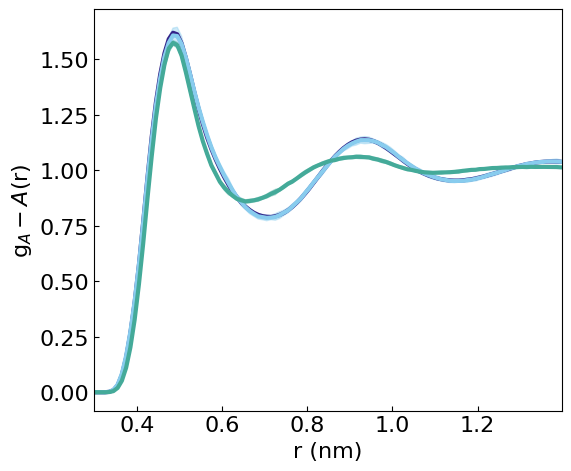

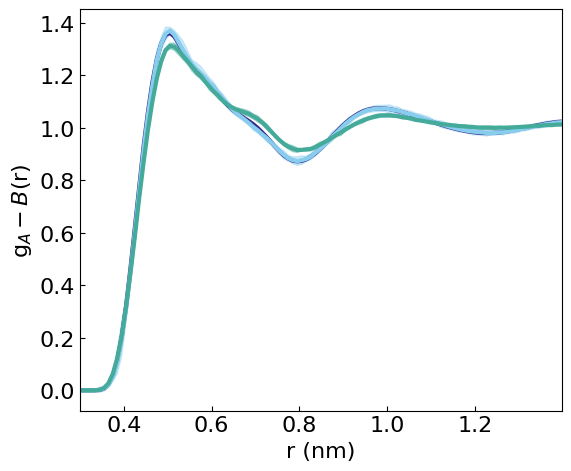

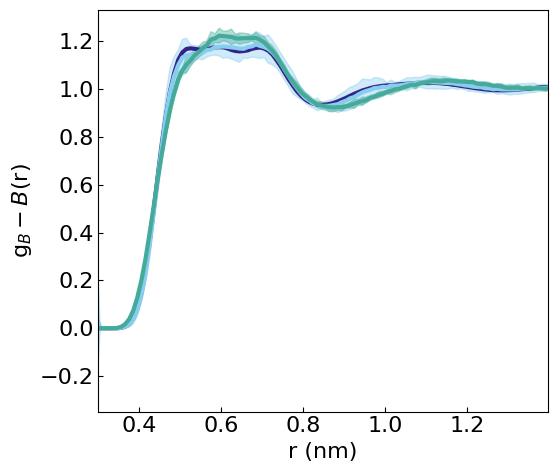

In [13]:
import cgbench

trajectories = [
    np.array(results['three-site']['ref']['traj']),
    np.array(results['three-site']['mace']['N=20']['corr=2']['traj']),
    np.array(results['three-site']['classical']['traj'])
]

labels = [
    'Reference',
    'MLP',
    'Classical'
]

n_chains = 10 # Only show 10 chains for ML models
is_single_chain = [traj.ndim == 3 for traj in trajectories]
rdf_data_all_chains = []

for chain in range(n_chains):
    trajs_single_chain = []
    for traj_chain, single in zip(trajectories, is_single_chain):
        if single:
            # Reference → do NOT index by chain
            trajs_single_chain.append(traj_chain)
        else:
            # ML models → pick chain
            trajs_single_chain.append(traj_chain[chain])

    rdf_data_chain, bead_combos = utils.structural.calculate_rdf(
        trajs_single_chain,
        ['A','B','A'],
        sites_per_mol=3,
        pair_batch_size=10_000,
        frame_batch_size=1_000
    )
    rdf_data_all_chains.append(rdf_data_chain)


merged_rdf = {}

for bead_combo in bead_combos:
    merged_rdf[bead_combo] = {}

    for traj_idx in range(len(trajectories)):

        chain_curves = []
        for chain_idx in range(n_chains):
            r, g_r = rdf_data_all_chains[chain_idx][bead_combo][traj_idx]
            chain_curves.append((r, g_r))

        merged_rdf[bead_combo][traj_idx] = chain_curves


for bead_combo in bead_combos:
    for traj_idx in merged_rdf[bead_combo]:
        curves = merged_rdf[bead_combo][traj_idx]

        r_vals = np.array([c[0] for c in curves])   # shape (n_chains, bins)
        g_vals = np.array([c[1] for c in curves])   # shape (n_chains, bins)

        merged_rdf[bead_combo][traj_idx] = (r_vals, g_vals)
        
results['three-site']['rdf'] = merged_rdf

cgbench.plotting.structural.plot_rdf(
    merged_rdf,
    bead_combos,
    labels,
    mode="multi",  
    n_std=3.0,
    show_legend=False,
    save_pdf=False
)

Reference shape: (500000, 300, 3)
MLP shape: (10, 2000, 300, 3)
Classical shape: (10, 2001, 300, 3)
Number of atoms: 300
Number of molecules: 100
Species array length: 300
Processing Reference...
[ADF] Estimates 464116 max. triplets in neighbor list and 463672 max. triplets in cutoff-shell.
[ADF] Estimates 464116 max. triplets in neighbor list and 463672 max. triplets in cutoff-shell.
Processing MLP chain 1/10...
[ADF] Estimates 454360 max. triplets in neighbor list and 453712 max. triplets in cutoff-shell.
[ADF] Estimates 454360 max. triplets in neighbor list and 453712 max. triplets in cutoff-shell.
Processing MLP chain 2/10...
[ADF] Estimates 461792 max. triplets in neighbor list and 461084 max. triplets in cutoff-shell.
[ADF] Estimates 461792 max. triplets in neighbor list and 461084 max. triplets in cutoff-shell.
Processing MLP chain 3/10...
[ADF] Estimates 461196 max. triplets in neighbor list and 460296 max. triplets in cutoff-shell.
[ADF] Estimates 461196 max. triplets in neigh

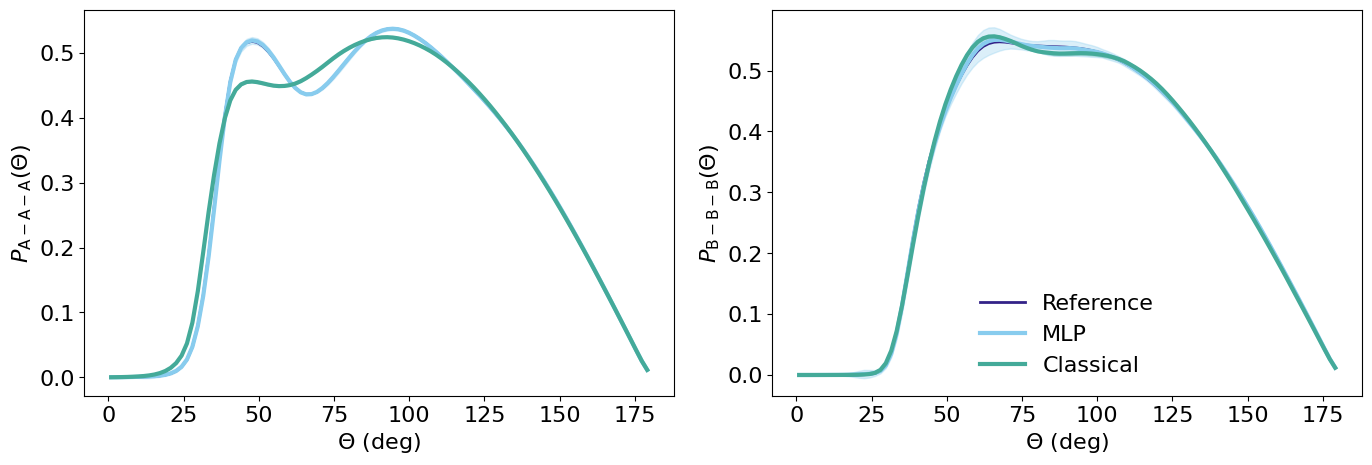

In [253]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from typing import NamedTuple

# Imports from your environment
from jax_md_mod.custom_quantity import init_adf_nbrs, ADFParams, adf_discretization
from jax_md import partition

# 1. Boilerplate / Helper Classes
class State(NamedTuple):
    position: jnp.ndarray

def calculate_species_adf(positions, species_labels, target_triplet, displacement_fn, adf_params, box_size):
    """
    Computes averaged ADF for a specific triplet combination with padding to handle JAX MD neighbor lists.
    """
    n_frames = positions.shape[0]
    nbins = len(adf_params.adf_bin_centers)
    
    # 1. Initialize Neighbor List (using standard, unpadded size)
    # Note: We still build the list based on the real atoms (0-299).
    neighbor_fn = partition.neighbor_list(
        displacement_fn, box_size, r_cutoff=adf_params.r_outer, capacity_multiplier=2
    )
    nbrs = neighbor_fn.allocate(positions[0])
    
    # 2. Prepare Padded Arrays (Size N+1)
    # We add one dummy atom at the end so index 300 is valid.
    # Pad positions: (300, 3) -> (301, 3)
    r_init_padded = jnp.pad(positions[0], ((0, 1), (0, 0)), constant_values=0.0)
    
    # Pad species: (300,) -> (301,)
    # Use a dummy species ID (e.g., -1) for the padding atom
    species_padded = jnp.pad(species_labels, (0, 1), constant_values=-1)
    
    # 3. Initialize ADF function
    # Pass the PADDED position so the static analysis can handle the '300' index
    adf_fn = init_adf_nbrs(
        displacement_fn, 
        adf_params, 
        adf_species=target_triplet, 
        r_init=r_init_padded,  # <--- Use padded here
        nbrs_init=nbrs
    )
    
    @jax.jit
    def compute_frame(pos, neighbor):
        # Update neighbors using REAL positions (physics depends on real atoms)
        neighbor = neighbor.update(pos)
        
        # Pad positions for the calculation step (memory access depends on padded indices)
        pos_padded = jnp.pad(pos, ((0, 1), (0, 0)), constant_values=0.0)
        
        # Pass padded positions and padded species
        val = adf_fn(State(position=pos_padded), neighbor, species=species_padded)
        return val, neighbor

    avg_adf = jnp.zeros(nbins)
    
    # Loop over frames
    for i in range(n_frames):
        # positions[i] is (300, 3), which is correct for neighbor.update
        val, nbrs = compute_frame(positions[i], nbrs)
        avg_adf += val[0]
        
    return avg_adf / n_frames

# --- 2. Configuration ---

N_BINS = 100
R_INNER = 0.0
R_OUTER =  0.8
BOX_SIZE = BOX_LENGTH

bead_types = ['A','B','A']
n_molecules = 100
full_bead_types = np.tile(bead_types, n_molecules)
full_bead_types.shape

# Discretization
bin_centers, sigma_adf = adf_discretization(nbins=N_BINS)
params = ADFParams(
    reference=None, 
    adf_bin_centers=bin_centers, 
    sigma=sigma_adf, 
    r_outer=R_OUTER, 
    r_inner=R_INNER
)

# --- 3. Data Processing ---

# Flatten trajectories properly to (n_frames, n_atoms, 3)
ref_sub = results['three-site']['ref']['traj']#[::10]
n_atoms = 300
n_molecules = n_atoms // 3

# Keep trajectories as (n_chains, n_frames, n_atoms, 3)
mlp_traj = np.array(results['three-site']['mace']['N=20']['corr=2']['traj'])[:10,:,:,:]
cla_traj = np.array(results['three-site']['classical']['traj'])[:,:,:,:]

# Check shape 
print("Reference shape:", ref_sub.shape)
print("MLP shape:", mlp_traj.shape)
print("Classical shape:", cla_traj.shape)
print("Number of atoms:", n_atoms)
print("Number of molecules:", n_molecules)

# Species Setup for molecules with 3 atoms each (A-B-A pattern)
species_single_mol = jnp.array([0, 1, 0])
species_all = jnp.tile(species_single_mol, n_molecules)

# Verify species array matches atom count
print("Species array length:", len(species_all))
assert len(species_all) == n_atoms, f"Species length {len(species_all)} != n_atoms {n_atoms}"

AAA_triplet = jnp.array([[0, 0, 0]])
BBB_triplet = jnp.array([[1, 1, 1]])

# Process reference (single trajectory)
print("Processing Reference...")
ref_aaa = calculate_species_adf(ref_sub, species_all, AAA_triplet, disp_fn_X, params, BOX_SIZE)
ref_bbb = calculate_species_adf(ref_sub, species_all, BBB_triplet, disp_fn_X, params, BOX_SIZE)

# Process each chain individually for MLP and Classical
n_chains_mlp = mlp_traj.shape[0]
n_chains_cla = cla_traj.shape[0]

mlp_aaa_chains = []
mlp_bbb_chains = []
for i in range(n_chains_mlp):
    print(f"Processing MLP chain {i+1}/{n_chains_mlp}...")
    mlp_aaa_chains.append(calculate_species_adf(mlp_traj[i], species_all, AAA_triplet, disp_fn_X, params, BOX_SIZE))
    mlp_bbb_chains.append(calculate_species_adf(mlp_traj[i], species_all, BBB_triplet, disp_fn_X, params, BOX_SIZE))

cla_aaa_chains = []
cla_bbb_chains = []
for i in range(n_chains_cla):
    print(f"Processing Classical chain {i+1}/{n_chains_cla}...")
    cla_aaa_chains.append(calculate_species_adf(cla_traj[i], species_all, AAA_triplet, disp_fn_X, params, BOX_SIZE))
    cla_bbb_chains.append(calculate_species_adf(cla_traj[i], species_all, BBB_triplet, disp_fn_X, params, BOX_SIZE))

# Convert to arrays for mean/std calculation
mlp_aaa_arr = np.array(mlp_aaa_chains)
mlp_bbb_arr = np.array(mlp_bbb_chains)
cla_aaa_arr = np.array(cla_aaa_chains)
cla_bbb_arr = np.array(cla_bbb_chains)

from cgbench.plotting import style

style.setup_plot_style()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
theta_deg = jnp.degrees(bin_centers)

n_std = 3

# AAA plot
ax1.plot(theta_deg, ref_aaa, label='Reference', lw=2, color=style.color_ref)
ax1.plot(theta_deg, mlp_aaa_arr.mean(axis=0), label='MLP', color=style.color_mace)
ax1.fill_between(theta_deg, mlp_aaa_arr.mean(axis=0) - n_std * mlp_aaa_arr.std(axis=0), 
                 mlp_aaa_arr.mean(axis=0) + n_std * mlp_aaa_arr.std(axis=0), alpha=0.3, color=style.color_mace)
ax1.plot(theta_deg, cla_aaa_arr.mean(axis=0), label='Classical', color=style.color_fm)
ax1.fill_between(theta_deg, cla_aaa_arr.mean(axis=0) - n_std * cla_aaa_arr.std(axis=0),
                 cla_aaa_arr.mean(axis=0) + n_std * cla_aaa_arr.std(axis=0), alpha=0.3, color=style.color_fm)
ax1.set_xlabel(r'$\Theta$ (deg)')
ax1.set_ylabel(r"$P_{\mathrm{A-A-A}}(\Theta)$")

# BBB plot
ax2.plot(theta_deg, ref_bbb, label='Reference', lw=2, color=style.color_ref)
ax2.plot(theta_deg, mlp_bbb_arr.mean(axis=0), label='MLP', color=style.color_mace)
ax2.fill_between(theta_deg, mlp_bbb_arr.mean(axis=0) - n_std * mlp_bbb_arr.std(axis=0), 
                 mlp_bbb_arr.mean(axis=0) + n_std * mlp_bbb_arr.std(axis=0), alpha=0.3, color=style.color_mace)
ax2.plot(theta_deg, cla_bbb_arr.mean(axis=0), label='Classical', color=style.color_fm)
ax2.fill_between(theta_deg, cla_bbb_arr.mean(axis=0) - n_std * cla_bbb_arr.std(axis=0),
                 cla_bbb_arr.mean(axis=0) + n_std * cla_bbb_arr.std(axis=0), alpha=0.3, color=style.color_fm)
ax2.set_xlabel(r'$\Theta$ (deg)')
ax2.set_ylabel(r"$P_{\mathrm{B-B-B}}(\Theta)$")
ax2.legend(frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig("hexane_three_site_adf.pdf", dpi=300, bbox_inches='tight')
plt.show()


## Two-site

### Ref

In [229]:
path = "../data/reference_simulations/hexane/hexane_ttot=100ns_dt=1fs_nstxout=200_CG=two-site.npz"
data = dict(np.load(path,allow_pickle=True))
ref_traj = np.concatenate([data['arr_0'].item()['training']['R'], data['arr_0'].item()['validation']['R']])

bond_ref = [utils.geometry.compute_atom_distance(ref_traj, a, b, bond_util['two-site']['disp_X']) for a,b in bond_util['two-site']['idcs']]
bond_ref = np.concatenate(bond_ref)

results['two-site'] = {
    'ref': {
        'bonds': bond_ref,
        'traj': ref_traj
    }
}

In [230]:
idcs = jnp.array(bond_util['two-site']['idcs'])
def single_bond_distance(chain, bond_idx):
    a, b = bond_idx
    return utils.geometry.compute_atom_distance(chain, a, b, bond_util['two-site']['disp_X'])

### Classical

In [231]:
base_path = "../results/Hexane/Classical_potential/map=two-site/chain_"
trajectories = []
for chain_idx in range(10):
    print(f"Loading chain {chain_idx}")
    traj_path = base_path + str(chain_idx) + "/traj.xtc"
    conf_path = base_path + str(chain_idx) + "/cg_hexane.gro"
    traj = md.load(traj_path, top=conf_path).xyz
    trajectories.append(traj)

trajectories = np.array(trajectories)
vmap_bond = jax.vmap(single_bond_distance, in_axes=(None, 0))  
vmap_chain = jax.vmap(vmap_bond, in_axes=(0, None))  
bonds_classical = vmap_chain(jnp.array(trajectories), idcs)
bonds_classical = bonds_classical.reshape(bonds_classical.shape[0], -1)

results['two-site']['classical'] = {
    'bonds': bonds_classical,
    'traj': trajectories
}

Loading chain 0
Loading chain 1
Loading chain 2
Loading chain 3
Loading chain 4
Loading chain 5
Loading chain 6
Loading chain 7
Loading chain 8
Loading chain 9


### MACE

In [232]:
line_locs = utils.chains.get_line_locations(0, 1000, 50, print_every=0.5)
results['two-site']['mace'] = {}

for N in paths_two.keys():
    results['two-site']['mace'][N] = {}
    
    for bo in paths_two[N].keys():
        if paths_two[N][bo] == '':
            print(f"Two-site {N}, {bo}: No data")
            continue
        print(f"Two-site {N}, {bo}: {paths_two[N][bo]}")

        mace_traj_path = paths_two[N][bo]
        mace_traj = np.load(mace_traj_path, allow_pickle=True)
        mace_traj *= box[0,0]
        mace_traj = utils.chains.split_into_chains(mace_traj, line_locs) # shape (n_chains, n_frames, n_beads, 3)
        
        aux_path = mace_traj_path.replace('trajectory.pkl','traj_state_aux.pkl')
        aux_data = np.load(aux_path, allow_pickle=True)['kT']
        aux_data = utils.chains.split_into_chains(aux_data, line_locs)
        
        mace_traj = utils.chains.mark_nan(mace_traj, aux_data, threshold=5)
        mean_length, std_length = utils.chains.calculate_stability(mace_traj)
        print(f"Mean stable length: {mean_length} ± {std_length} ps")

        rdf_data, bead_combos = utils.structural.calculate_rdf(
            [results['two-site']['ref']['traj']] + list(mace_traj),
            ['A', 'A'], 
            sites_per_mol=2,
            pair_batch_size=10_000,
            frame_batch_size=1_000 
        )
        
        valid_chain_mask = np.array([~np.isnan(chain).any() for chain in mace_traj])
        mace_traj_valid = [chain for chain, ok in zip(mace_traj, valid_chain_mask) if ok]

        print(f"Valid chains kept: {len(mace_traj_valid)} / {len(mace_traj)}")
        if len(mace_traj_valid) == 0:
            print("No valid chains remain after NaN filtering.")
            continue
        
        vmap_bond = jax.vmap(single_bond_distance, in_axes=(None, 0))  
        vmap_chain = jax.vmap(vmap_bond, in_axes=(0, None))  
        bonds_mace = vmap_chain(jnp.array(mace_traj_valid), idcs)
        bonds_mace = bonds_mace.reshape(bonds_mace.shape[0], -1)
        print("bonds_mace.shape:", bonds_mace.shape)
        
        
        # Compute bond metrics for each chain
        cumulative_fractions = []
        nn_distances_list = []
        
        for chain_idx, chain_traj in enumerate(mace_traj_valid):
            cumulative_fraction, nearest_neighbor_distances, bonds_per_frame = \
                utils.chains.compute_bond_metrics(chain_traj, bond_util['two-site']['disp_X'])
            
            cumulative_fractions.append(cumulative_fraction)
            nn_distances_list.append(nearest_neighbor_distances)

        nn_distances_list = np.array(nn_distances_list)
        nn_distances_list = nn_distances_list.reshape(nn_distances_list.shape[0], -1)
        
        results['two-site']['mace'][N][bo] = {
            'bonds': bonds_mace,
            'traj': mace_traj_valid,
            'cumulative_switch_fraction': cumulative_fractions,
            'nn_distances': nn_distances_list
        }
        
        for bead_combo in bead_combos:
            MSE = []
            for i in range(1, len(mace_traj)+1):
                RDF_MSE = utils.structural.calculate_rdf_mse_from_dict(
                    rdf_data, 
                    bead_combo, 
                    0, 
                    i
                )
                MSE.append(RDF_MSE)
            
            MEAN_MSE = np.mean(MSE)
            STD_MSE = np.std(MSE)
            print(f"Mean RDF {bead_combo} MSE across chains: {MEAN_MSE*1000} ± {STD_MSE*1000}")
        print('\n')

Two-site N=10, corr=1: ../results/Hexane/MLP/Hexane_map=two-site_rcut=0.65_corr=1_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl
Mean stable length: 1000.0 ± 0.0 ps
Valid chains kept: 50 / 50
bonds_mace.shape: (50, 200000)
Mean RDF ('A', 'A') MSE across chains: 20.748064802858327 ± 3.0261824617020925


Two-site N=10, corr=2: ../results/Hexane/MLP/Hexane_map=two-site_rcut=0.65_corr=2_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl
Mean stable length: 1000.0 ± 0.0 ps
Valid chains kept: 50 / 50
bonds_mace.shape: (50, 200000)
Mean RDF ('A', 'A') MSE across chains: 5.164795407237885 ± 3.2336761956190916


Two-site N=10, corr=3: ../results/Hexane/MLP/Hexane_map=two-site_rcut=0.65_corr=3_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl
Mean stable length: 930.29 ± 188.824444656

### Two-site w/ Prior

#### Training

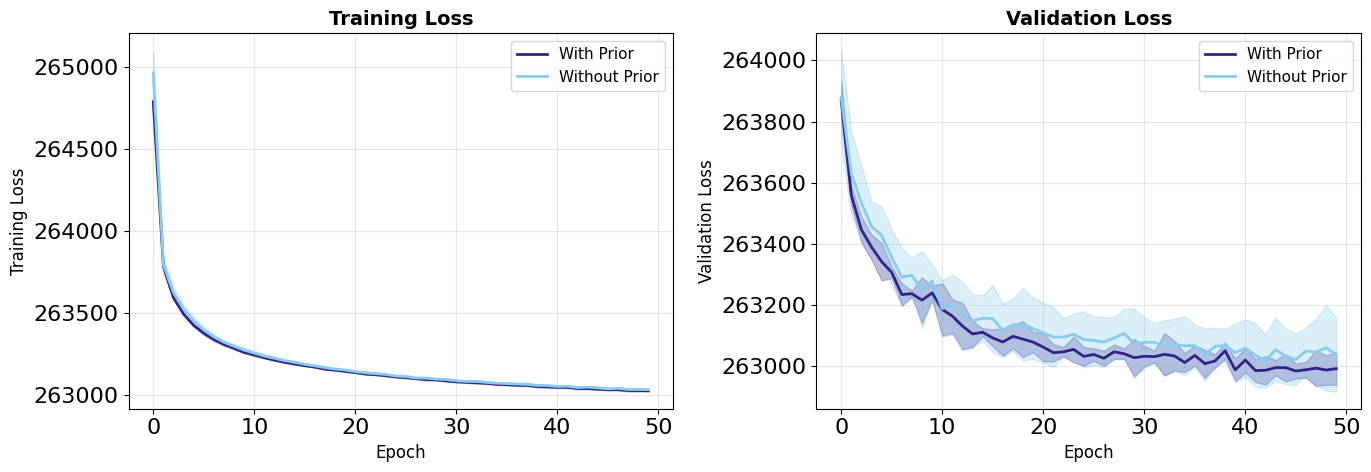

Final Training Loss (mean ± std):
  With Prior:    263025.29 ± 6.07
  Without Prior: 263031.63 ± 4.00

Final Validation Loss (mean ± std):
  With Prior:    262992.76 ± 52.81
  Without Prior: 263038.45 ± 120.97


In [31]:
import re
import numpy as np

def parse_force_matching_log(log_path):
    """
    Parse force matching log file and extract training and validation losses.
    
    Parameters:
    -----------
    log_path : str
        Path to the force_matching.log file
    
    Returns:
    --------
    train_loss : numpy.ndarray
        Array of average training losses for each epoch
    val_loss : numpy.ndarray
        Array of average validation losses for each epoch
    """
    train_losses = []
    val_losses = []
    
    # Regular expressions for multi-line format
    train_pattern = r'Average train loss: ([\d.]+)'
    val_pattern = r'Average val loss: ([\d.]+)'
    
    with open(log_path, 'r') as f:
        content = f.read()
        
        # Split by epoch markers
        epochs = re.split(r'\[Epoch \d+\]:', content)
        
        for epoch_block in epochs[1:]:  # Skip the first split (before first epoch)
            # Extract training loss
            train_match = re.search(train_pattern, epoch_block)
            # Extract validation loss
            val_match = re.search(val_pattern, epoch_block)
            
            if train_match and val_match:
                train_losses.append(float(train_match.group(1)))
                val_losses.append(float(val_match.group(1)))
    
    return np.array(train_losses), np.array(val_losses)


import numpy as np
import matplotlib.pyplot as plt
from cgbench.plotting import style
style.setup_plot_style()


paths_wo_prior = [
    "/home/franz/CG-Mapping-Benchmark/outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=2_corr=2_seed=21_prior=False/force_matching.log",
    "/home/franz/CG-Mapping-Benchmark/results/Hexane/MLP/Hexane_map=two-site_rcut=0.8_corr=2_int=2/force_matching.log",
    "/home/franz/CG-Mapping-Benchmark/outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=2_corr=2_seed=23_prior=False/force_matching.log",
]
paths_w_prior = [
    "/home/franz/CG-Mapping-Benchmark/outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=2_corr=2_seed=21_prior=True/force_matching.log",
    "/home/franz/CG-Mapping-Benchmark/outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=2_corr=2_seed=22_prior=True/force_matching.log",
    "/home/franz/CG-Mapping-Benchmark/outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=2_corr=2_seed=23_prior=True/force_matching.log",
]

with_prior_train = []
with_prior_val = []
without_prior_train = []
without_prior_val = []

for path in paths_w_prior:
    train, val = parse_force_matching_log(path)
    with_prior_train.append(train)
    with_prior_val.append(val)

for path in paths_wo_prior:
    train, val = parse_force_matching_log(path)
    without_prior_train.append(train)
    without_prior_val.append(val)

# Convert to arrays (seeds x epochs)
with_prior_train = np.array(with_prior_train)
with_prior_val = np.array(with_prior_val)
without_prior_train = np.array(without_prior_train)
without_prior_val = np.array(without_prior_val)

# Calculate mean and std across seeds
with_prior_train_mean = with_prior_train.mean(axis=0)
with_prior_train_std = with_prior_train.std(axis=0)
with_prior_val_mean = with_prior_val.mean(axis=0)
with_prior_val_std = with_prior_val.std(axis=0)

without_prior_train_mean = without_prior_train.mean(axis=0)
without_prior_train_std = without_prior_train.std(axis=0)
without_prior_val_mean = without_prior_val.mean(axis=0)
without_prior_val_std = without_prior_val.std(axis=0)

# Create epochs array
n_epochs = len(with_prior_train_mean)
epochs = np.arange(n_epochs)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot training loss
ax1.plot(epochs, with_prior_train_mean, label='With Prior', color=style.colors_extended[0], linewidth=2)
ax1.fill_between(epochs, 
                with_prior_train_mean - with_prior_train_std,
                with_prior_train_mean + with_prior_train_std,
                alpha=0.3, color=style.colors_extended[0])

ax1.plot(epochs, without_prior_train_mean, label='Without Prior', color=style.colors_extended[1], linewidth=2)
ax1.fill_between(epochs,
                without_prior_train_mean - without_prior_train_std,
                without_prior_train_mean + without_prior_train_std,
                alpha=0.3, color=style.colors_extended[1])

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Loss', fontsize=12)
ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot validation loss
ax2.plot(epochs, with_prior_val_mean, label='With Prior', color=style.colors_extended[0], linewidth=2)
ax2.fill_between(epochs,
                with_prior_val_mean - with_prior_val_std,
                with_prior_val_mean + with_prior_val_std,
                alpha=0.3, color=style.colors_extended[0])

ax2.plot(epochs, without_prior_val_mean, label='Without Prior', color=style.colors_extended[1], linewidth=2)
ax2.fill_between(epochs,
                without_prior_val_mean - without_prior_val_std,
                without_prior_val_mean + without_prior_val_std,
                alpha=0.3, color=style.colors_extended[1])

ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Validation Loss', fontsize=12)
ax2.set_title('Validation Loss', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Print final statistics
print("Final Training Loss (mean ± std):")
print(f"  With Prior:    {with_prior_train_mean[-1]:.2f} ± {with_prior_train_std[-1]:.2f}")
print(f"  Without Prior: {without_prior_train_mean[-1]:.2f} ± {without_prior_train_std[-1]:.2f}")
print("\nFinal Validation Loss (mean ± std):")
print(f"  With Prior:    {with_prior_val_mean[-1]:.2f} ± {with_prior_val_std[-1]:.2f}")
print(f"  Without Prior: {without_prior_val_mean[-1]:.2f} ± {without_prior_val_std[-1]:.2f}")


#### Parameter Estimation

In [30]:
all_lengths = results['two-site']['ref']['bonds'].flatten() 

mean_r = jnp.mean(all_lengths)
log_b0_est = jnp.log(mean_r)

kT = quantity.kb * 300
variance_r = jnp.var(all_lengths)
kb_est = kT / variance_r
log_kb_est = jnp.log(kb_est)

print(f"Estimated log_b0: {log_b0_est}, log_kb: {log_kb_est}")

Estimated log_b0: -0.9802775382995605, log_kb: 8.701623916625977


b0 = 0.3752 nm
kb = 6012.67 kJ/(mol·nm²)


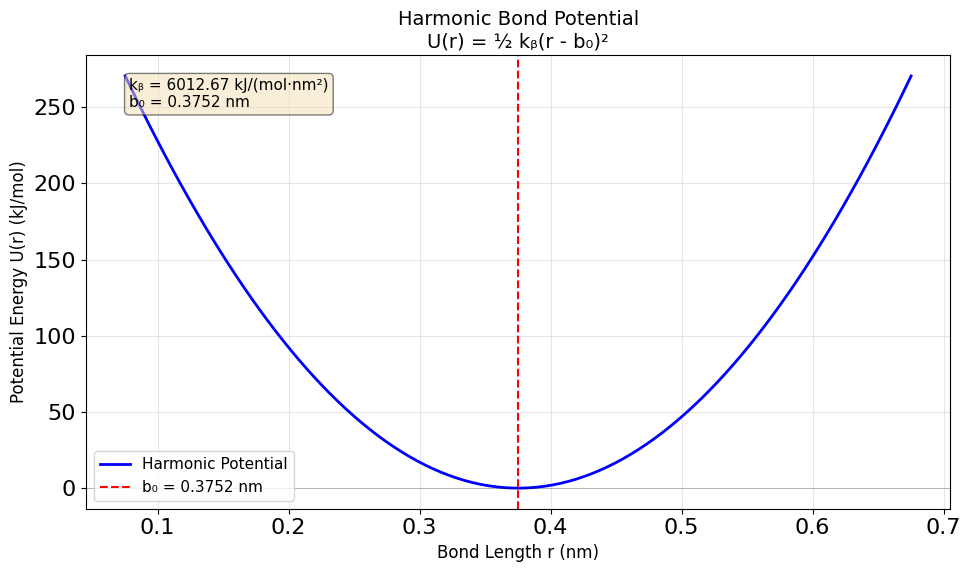

In [29]:
from matplotlib import pyplot as plt
import numpy as np

# Convert from log space
b0 = np.exp(log_b0_est)
kb = kb_est

print(f"b0 = {b0:.4f} nm")
print(f"kb = {kb:.2f} kJ/(mol·nm²)")

# Generate bond length values around the equilibrium
r = np.linspace(b0 - 0.3, b0 + 0.3, 200)
U = 0.5 * kb * (r - b0)**2

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(r, U, 'b-', linewidth=2, label='Harmonic Potential')
plt.axvline(b0, color='r', linestyle='--', linewidth=1.5, label=f'b₀ = {b0:.4f} nm')
plt.axhline(0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

plt.xlabel('Bond Length r (nm)', fontsize=12)
plt.ylabel('Potential Energy U(r) (kJ/mol)', fontsize=12)
plt.title('Harmonic Bond Potential\nU(r) = ½ kᵦ(r - b₀)²', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Add text box with parameters
textstr = f'kᵦ = {kb:.2f} kJ/(mol·nm²)\nb₀ = {b0:.4f} nm'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

#### Comparison

In [42]:
traj_paths_w_prior = [
    "/home/franz/CG-Mapping-Benchmark/outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=2_corr=2_seed=21_prior=True/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl",
    "/home/franz/CG-Mapping-Benchmark/outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=2_corr=2_seed=22_prior=True/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl",
    "/home/franz/CG-Mapping-Benchmark/outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=2_corr=2_seed=23_prior=True/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl",
]
traj_paths_wo_prior = [
    "/home/franz/CG-Mapping-Benchmark/results/Hexane/MLP/Hexane_map=two-site_rcut=0.8_corr=2_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl",
    "/home/franz/CG-Mapping-Benchmark/outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=2_corr=2_seed=21_prior=False/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl",
    "/home/franz/CG-Mapping-Benchmark/outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=2_corr=2_seed=23_prior=False/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl",
]

paths_prior = {
    'with_prior': traj_paths_w_prior,
    'without_prior': traj_paths_wo_prior
}

In [44]:
line_locs = utils.chains.get_line_locations(0, 1000, 50, print_every=0.5)
results_prior = {}

for prior_key in paths_prior.keys():
    print(f"--- Processing MACE trajectories ({prior_key}) ---")
    results_prior[prior_key] = {}
    for idx, traj_path in enumerate(paths_prior[prior_key]):
        mace_traj = np.load(traj_path, allow_pickle=True)
        mace_traj *= box[0,0]
        mace_traj = utils.chains.split_into_chains(mace_traj, line_locs) # shape (n_chains, n_frames, n_beads, 3)

        aux_path = traj_path.replace('trajectory.pkl','traj_state_aux.pkl')
        aux_data = np.load(aux_path, allow_pickle=True)['kT']
        aux_data = utils.chains.split_into_chains(aux_data, line_locs)
        

        mace_traj = utils.chains.mark_nan(mace_traj, aux_data, threshold=5)
        mean_length, std_length = utils.chains.calculate_stability(mace_traj)
        print(f"Mean stable length: {mean_length} ± {std_length} ps")

        rdf_data, bead_combos = utils.structural.calculate_rdf(
            [results['two-site']['ref']['traj']] + list(mace_traj),
            ['A', 'A'], 
            sites_per_mol=2,
            pair_batch_size=10_000,
            frame_batch_size=1_000 
        )

        valid_chain_mask = np.array([~np.isnan(chain).any() for chain in mace_traj])
        mace_traj_valid = [chain for chain, ok in zip(mace_traj, valid_chain_mask) if ok]

        print(f"Valid chains kept: {len(mace_traj_valid)} / {len(mace_traj)}")
        if len(mace_traj_valid) == 0:
            print("No valid chains remain after NaN filtering.")
            continue

        vmap_bond = jax.vmap(single_bond_distance, in_axes=(None, 0))  
        vmap_chain = jax.vmap(vmap_bond, in_axes=(0, None))  
        bonds_mace = vmap_chain(jnp.array(mace_traj_valid), idcs)
        bonds_mace = bonds_mace.reshape(bonds_mace.shape[0], -1)
        print("bonds_mace.shape:", bonds_mace.shape)


        # Compute bond metrics for each chain
        cumulative_fractions = []
        nn_distances_list = []

        for chain_idx, chain_traj in enumerate(mace_traj_valid):
            cumulative_fraction, nearest_neighbor_distances, bonds_per_frame = \
                utils.chains.compute_bond_metrics(chain_traj, bond_util['two-site']['disp_X'])
            
            cumulative_fractions.append(cumulative_fraction)
            nn_distances_list.append(nearest_neighbor_distances)

        nn_distances_list = np.array(nn_distances_list)
        nn_distances_list = nn_distances_list.reshape(nn_distances_list.shape[0], -1)

        results_prior[prior_key][idx] = {
            'bonds': bonds_mace,
            'traj': mace_traj_valid,
            'cumulative_switch_fraction': cumulative_fractions,
            'nn_distances': nn_distances_list,
            'mean_length': mean_length,
            'std_length': std_length
        }
        
        print("Shape after filtering:", np.array(mace_traj_valid).shape)

        for bead_combo in bead_combos:
            MSE = []
            for i in range(1, len(mace_traj)+1):
                RDF_MSE = utils.structural.calculate_rdf_mse_from_dict(
                    rdf_data, 
                    bead_combo, 
                    0, 
                    i
                )
                MSE.append(RDF_MSE)
            
            MEAN_MSE = np.mean(MSE)
            STD_MSE = np.std(MSE)
            print(f"Mean RDF {bead_combo} MSE across chains: {MEAN_MSE*1000} ± {STD_MSE*1000}")
        print('\n')

--- Processing MACE trajectories (with_prior) ---
Chain 6 exceeded threshold
Chain 14 exceeded threshold
Chain 18 exceeded threshold
Chain 21 exceeded threshold
Chain 28 exceeded threshold
Chain 32 exceeded threshold
Chain 33 exceeded threshold
Chain 38 exceeded threshold
Chain 39 exceeded threshold
Chain 42 exceeded threshold
Chain 45 exceeded threshold
Chain 46 exceeded threshold
Chain 48 exceeded threshold
Mean stable length: 890.95 ± 231.36439332792762 ps
Valid chains kept: 37 / 50
bonds_mace.shape: (37, 200000)
Shape after filtering: (37, 2000, 200, 3)
Mean RDF ('A', 'A') MSE across chains: 0.048146973393480244 ± 0.13989054540381318


Chain 0 exceeded threshold
Chain 2 exceeded threshold
Chain 6 exceeded threshold
Chain 7 exceeded threshold
Chain 8 exceeded threshold
Chain 9 exceeded threshold
Chain 10 exceeded threshold
Chain 12 exceeded threshold
Chain 13 exceeded threshold
Chain 14 exceeded threshold
Chain 15 exceeded threshold
Chain 16 exceeded threshold
Chain 17 exceeded thre

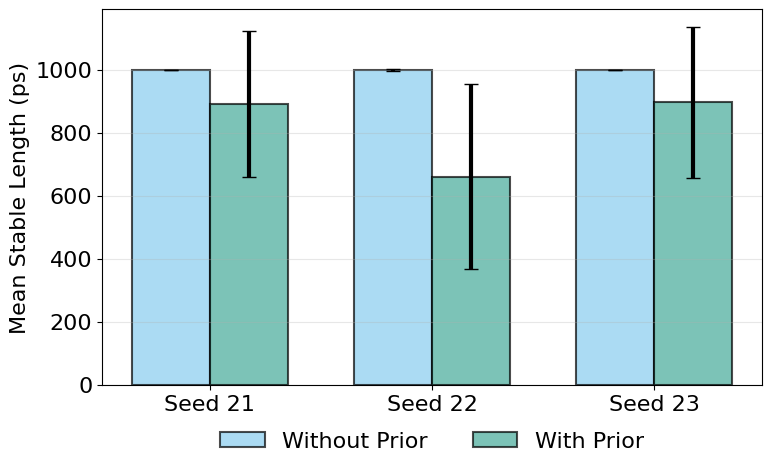

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from cgbench.plotting import style

style.setup_plot_style()

# Extract mean and std lengths for with and without prior
with_prior_means = []
with_prior_stds = []
without_prior_means = []
without_prior_stds = []

for idx in results_prior['with_prior'].keys():
    with_prior_means.append(results_prior['with_prior'][idx]['mean_length'])
    with_prior_stds.append(results_prior['with_prior'][idx]['std_length'])

for idx in results_prior['without_prior'].keys():
    without_prior_means.append(results_prior['without_prior'][idx]['mean_length'])
    without_prior_stds.append(results_prior['without_prior'][idx]['std_length'])

# Create bar plot with individual seeds
fig, ax = plt.subplots(figsize=(8, 5))

n_seeds = len(with_prior_means)
x = np.arange(n_seeds)
width = 0.35

# Plot bars for each seed
bars1 = ax.bar(x - width/2, without_prior_means, width, yerr=without_prior_stds, 
               capsize=5, alpha=0.7, color=style.colors[0], edgecolor='black', 
               linewidth=1.5, label='Without Prior')
bars2 = ax.bar(x + width/2, with_prior_means, width, yerr=with_prior_stds, 
               capsize=5, alpha=0.7, color=style.colors[1], edgecolor='black', 
               linewidth=1.5, label='With Prior')

ax.set_ylabel('Mean Stable Length (ps)', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels([f'Seed {21+i}' for i in range(n_seeds)], fontsize=16)
ax.grid(axis='y', alpha=0.3)

# Move legend outside with 2 columns
ax.legend(fontsize=16, loc='center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

plt.tight_layout()
plt.savefig('stable_length_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()


Processing bond data for 'Reference': (50000000,)
Processing bond data for 'MLP (without prior)': (10, 200000)
Plotting bond distribution for 'MLP (without prior)': 10 chains, mean=1.0, std sum=0.21584234016635617
Processing bond data for 'MLP (with prior)': (10, 200000)
Plotting bond distribution for 'MLP (with prior)': 10 chains, mean=1.0, std sum=0.011526692929056778


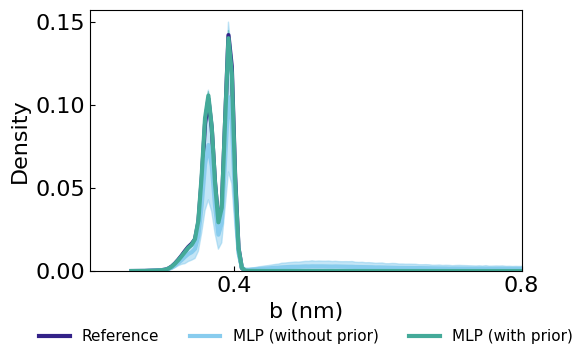

In [91]:
from cgbench.plotting import distributions

fig, ax = plt.subplots(figsize=(6,4))
distributions.plot_1d_bond(
    ax,
    [
        results['two-site']['ref']['bonds'],
        results_prior['without_prior'][0]['bonds'][:10],
        results_prior['with_prior'][0]['bonds'][:10],
    ],
    labels=[
        'Reference',
        'MLP (without prior)',
        'MLP (with prior)',
    ],
    mode = "multi",  
    n_std = 3,
    bins=400,
    tick_bin=0.4,
)
ax.set_ylabel("Density")
ax.set_xlim(0.2, 0.8)
ax.legend(fontsize=11, loc='center', bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig('bond_length_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

Saved RDF plot for A-A pairs to rdf_A-A.pdf
Generated 1 RDF plots saved as PDF files.


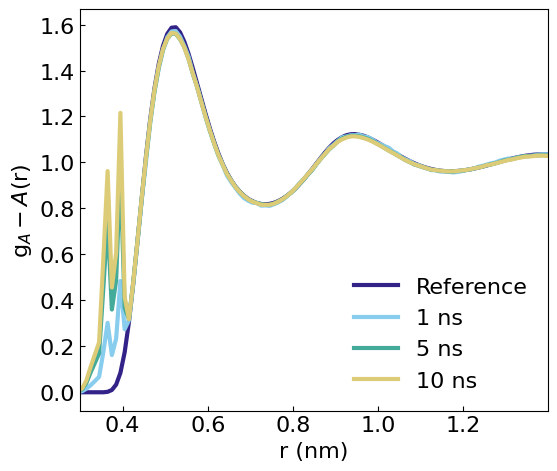

In [123]:
n_chains = 1

mace_traj = np.load("/home/franz/CG-Mapping-Benchmark/outputs/MLP_train/Hexane_map=two-site_tr=0.9_rcut=0.8_epochs=50_int=3_corr=2_seed=22_prior=False/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=10000_nmol=100_nchains=1_mode=sampling_seed=23/trajectory.pkl", allow_pickle=True)
mace_traj *= box[0,0]

cumulative_fraction, nearest_neighbor_distances, bonds_per_frame = \
utils.chains.compute_bond_metrics(mace_traj, bond_util['two-site']['disp_X'])

trajectories = [
    np.array(results['two-site']['ref']['traj']),
    np.array(mace_traj[:2000]),
    np.array(mace_traj[:10000]),
    np.array(mace_traj[:20000]),
]

labels = [
    'Reference',
    r'1 ns',
    r'5 ns',
    r'10 ns',
]

is_single_chain = [traj.ndim == 3 for traj in trajectories]
rdf_data_all_chains = []

for chain in range(n_chains):
    trajs_single_chain = []
    for traj_chain, single in zip(trajectories, is_single_chain):
        if single:
            # Reference → do NOT index by chain
            trajs_single_chain.append(traj_chain)
        else:
            # ML models → pick chain
            trajs_single_chain.append(traj_chain[chain])

    rdf_data_chain, bead_combos = utils.structural.calculate_rdf(
        trajs_single_chain,
        ['A','A'],
        sites_per_mol=2,
        pair_batch_size=10_000,
        frame_batch_size=1_000
    )
    rdf_data_all_chains.append(rdf_data_chain)
    
merged_rdf = {}

for bead_combo in bead_combos:
    merged_rdf[bead_combo] = {}

    for traj_idx in range(len(trajectories)):

        chain_curves = []
        for chain_idx in range(n_chains):
            r, g_r = rdf_data_all_chains[chain_idx][bead_combo][traj_idx]
            chain_curves.append((r, g_r))

        merged_rdf[bead_combo][traj_idx] = chain_curves


for bead_combo in bead_combos:
    for traj_idx in merged_rdf[bead_combo]:
        curves = merged_rdf[bead_combo][traj_idx]

        r_vals = np.array([c[0] for c in curves])   # shape (n_chains, bins)
        g_vals = np.array([c[1] for c in curves])   # shape (n_chains, bins)

        merged_rdf[bead_combo][traj_idx] = (r_vals, g_vals)

results['two-site']['rdf'] = merged_rdf

plotting.structural.plot_rdf(
    merged_rdf,
    bead_combos,
    labels,
    mode="multi",  
    n_std=3.0,
    show_legend=True,
    save_pdf=True
)


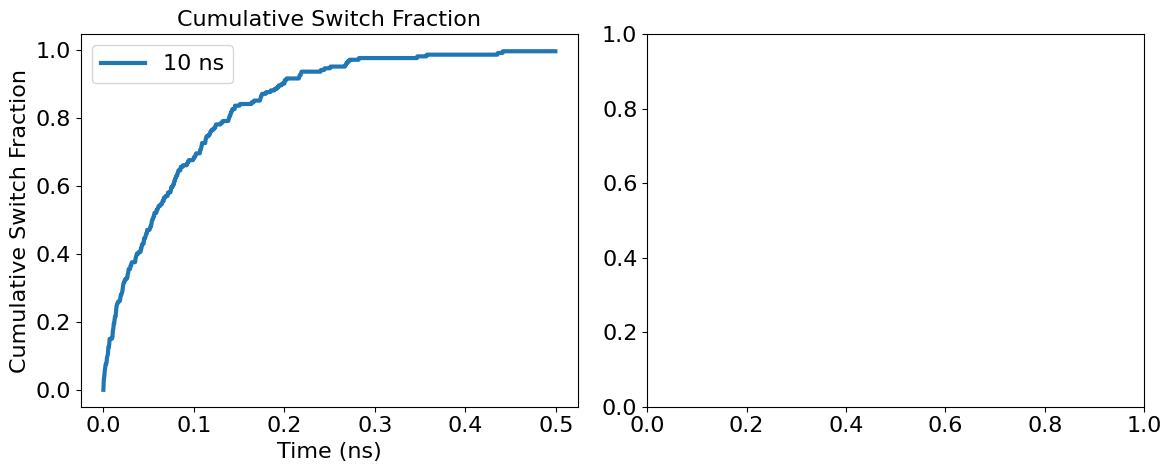

In [132]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot cumulative fraction
time_10ns = np.arange(len(cumulative_fraction[:1000])) * 0.5 / 1000

axes[0].plot(time_10ns, cumulative_fraction[:1000], label='10 ns')
axes[0].set_xlabel('Time (ns)')
axes[0].set_ylabel('Cumulative Switch Fraction')
axes[0].legend()
axes[0].set_title('Cumulative Switch Fraction')

plt.tight_layout()
plt.show()


Saved RDF plot for A-A pairs to rdf_A-A.pdf
Generated 1 RDF plots saved as PDF files.


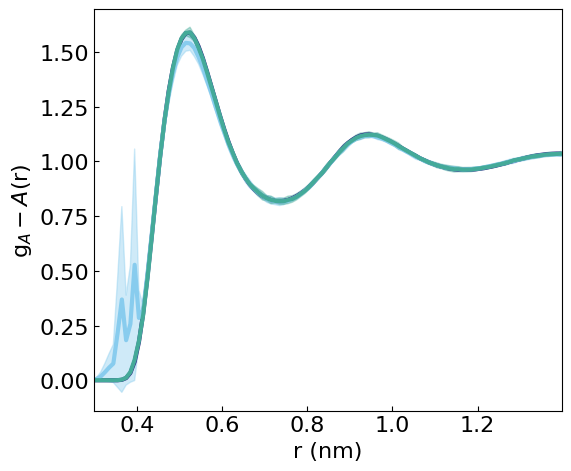

In [89]:
n_chains = 10

trajectories = [
    np.array(results['two-site']['ref']['traj']),
    np.array(results_prior['without_prior'][0]['traj'])[:n_chains],
    np.array(results_prior['with_prior'][0]['traj'])[:n_chains],
]

labels = [
    'Reference',
    'MLP without prior',
    'MLP with prior',
]

is_single_chain = [traj.ndim == 3 for traj in trajectories]
rdf_data_all_chains = []

for chain in range(n_chains):
    trajs_single_chain = []
    for traj_chain, single in zip(trajectories, is_single_chain):
        if single:
            # Reference → do NOT index by chain
            trajs_single_chain.append(traj_chain)
        else:
            # ML models → pick chain
            trajs_single_chain.append(traj_chain[chain])

    rdf_data_chain, bead_combos = utils.structural.calculate_rdf(
        trajs_single_chain,
        ['A','A'],
        sites_per_mol=2,
        pair_batch_size=10_000,
        frame_batch_size=1_000
    )
    rdf_data_all_chains.append(rdf_data_chain)
    
merged_rdf = {}

for bead_combo in bead_combos:
    merged_rdf[bead_combo] = {}

    for traj_idx in range(len(trajectories)):

        chain_curves = []
        for chain_idx in range(n_chains):
            r, g_r = rdf_data_all_chains[chain_idx][bead_combo][traj_idx]
            chain_curves.append((r, g_r))

        merged_rdf[bead_combo][traj_idx] = chain_curves


for bead_combo in bead_combos:
    for traj_idx in merged_rdf[bead_combo]:
        curves = merged_rdf[bead_combo][traj_idx]

        r_vals = np.array([c[0] for c in curves])   # shape (n_chains, bins)
        g_vals = np.array([c[1] for c in curves])   # shape (n_chains, bins)

        merged_rdf[bead_combo][traj_idx] = (r_vals, g_vals)

results['two-site']['rdf'] = merged_rdf

plotting.structural.plot_rdf(
    merged_rdf,
    bead_combos,
    labels,
    mode="multi",  
    n_std=3.0,
    show_legend=False,
    save_pdf=True
)


### plots

Processing bond data for 'Reference': (50000000,)
Processing bond data for 'Classical': (10, 200100)
Plotting bond distribution for 'Classical': 10 chains, mean=1.0, std sum=0.016047608952703393
Processing bond data for 'MLP': (50, 400000)
Plotting bond distribution for 'MLP': 50 chains, mean=1.0, std sum=0.01718434845383557


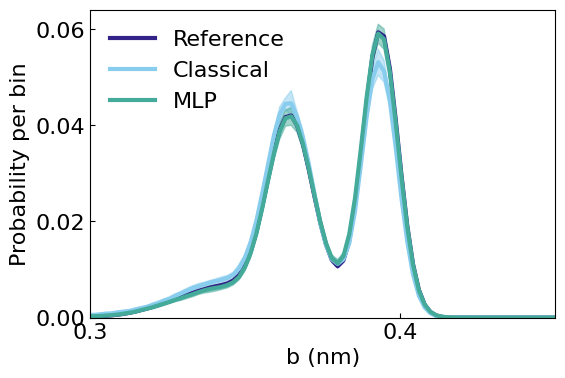

In [45]:
import importlib
import structural_analysis_utils
importlib.reload(structural_analysis_utils)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
structural_analysis_utils.plot_1d_bond(
    ax,
    [
        results['two-site']['ref']['bonds'],
        results['two-site']['classical']['bonds'],
        results['two-site']['mace']['N=20']['corr=2']['nn_distances'],
    ],
    labels=[
        'Reference',
        'Classical',
        'MLP'
    ],
    mode = "multi",  
    n_std = 3,
    bins=200,
    tick_bin=0.1
)
plt.xlim(0.3,0.45)
plt.show()

Reference shape: (500000, 200, 3)
MLP shape: (10, 2000, 200, 3)
Classical shape: (10, 2001, 200, 3)
Number of atoms: 200
Number of molecules: 100
Species array length: 200
Processing Reference...
[ADF] Estimates 127008 max. triplets in neighbor list and 126736 max. triplets in cutoff-shell.
Processing MLP chain 1/10...
[ADF] Estimates 123092 max. triplets in neighbor list and 122960 max. triplets in cutoff-shell.
Processing MLP chain 2/10...
[ADF] Estimates 127744 max. triplets in neighbor list and 127456 max. triplets in cutoff-shell.
Processing MLP chain 3/10...
[ADF] Estimates 128000 max. triplets in neighbor list and 128000 max. triplets in cutoff-shell.
Processing MLP chain 4/10...
[ADF] Estimates 129696 max. triplets in neighbor list and 129696 max. triplets in cutoff-shell.
Processing MLP chain 5/10...
[ADF] Estimates 121064 max. triplets in neighbor list and 121064 max. triplets in cutoff-shell.
Processing MLP chain 6/10...
[ADF] Estimates 129452 max. triplets in neighbor list 

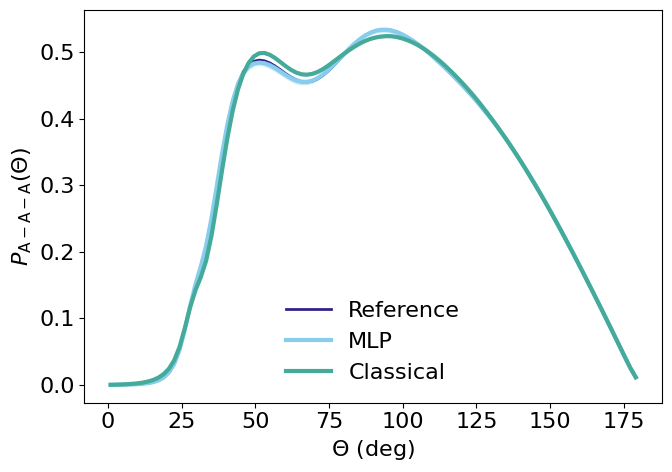

In [252]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from typing import NamedTuple

# Imports from your environment
from jax_md_mod.custom_quantity import adf_discretization, ADFParams

# 1. Boilerplate / Helper Classes
class State(NamedTuple):
    position: jnp.ndarray

# --- 2. Configuration ---

N_BINS = 100
R_INNER = 0.0
R_OUTER =  0.8
BOX_SIZE = BOX_LENGTH

bead_types = ['A','A']
n_molecules = 100
full_bead_types = np.tile(bead_types, n_molecules)
full_bead_types.shape

# Discretization
bin_centers, sigma_adf = adf_discretization(nbins=N_BINS)
params = ADFParams(
    reference=None, 
    adf_bin_centers=bin_centers, 
    sigma=sigma_adf, 
    r_outer=R_OUTER, 
    r_inner=R_INNER
)

# --- 3. Data Processing ---

# Flatten trajectories properly to (n_frames, n_atoms, 3)
ref_sub = results['two-site']['ref']['traj']#[::10]
n_atoms = 200
n_molecules = n_atoms // 2

# Keep trajectories as (n_chains, n_frames, n_atoms, 3)
mlp_traj = np.array(results['two-site']['mace']['N=20']['corr=2']['traj'])[:10,:,:,:]
cla_traj = np.array(results['two-site']['classical']['traj'])[:,:,:,:]

# Check shape 
print("Reference shape:", ref_sub.shape)
print("MLP shape:", mlp_traj.shape)
print("Classical shape:", cla_traj.shape)
print("Number of atoms:", n_atoms)
print("Number of molecules:", n_molecules)

# Species Setup for molecules with 2 atoms each (A-A pattern)
species_single_mol = jnp.array([0, 0])
species_all = jnp.tile(species_single_mol, n_molecules)

# Verify species array matches atom count
print("Species array length:", len(species_all))
assert len(species_all) == n_atoms, f"Species length {len(species_all)} != n_atoms {n_atoms}"

AAA_triplet = jnp.array([[0, 0, 0]])

# Process reference (single trajectory)
print("Processing Reference...")
ref_aaa = calculate_species_adf(ref_sub, species_all, AAA_triplet, disp_fn_X, params, BOX_SIZE)

# Process each chain individually for MLP and Classical
n_chains_mlp = mlp_traj.shape[0]
n_chains_cla = cla_traj.shape[0]

mlp_aaa_chains = []
for i in range(n_chains_mlp):
    print(f"Processing MLP chain {i+1}/{n_chains_mlp}...")
    mlp_aaa_chains.append(calculate_species_adf(mlp_traj[i], species_all, AAA_triplet, disp_fn_X, params, BOX_SIZE))

cla_aaa_chains = []
for i in range(n_chains_cla):
    print(f"Processing Classical chain {i+1}/{n_chains_cla}...")
    cla_aaa_chains.append(calculate_species_adf(cla_traj[i], species_all, AAA_triplet, disp_fn_X, params, BOX_SIZE))

# Convert to arrays for mean/std calculation
mlp_aaa_arr = np.array(mlp_aaa_chains)
cla_aaa_arr = np.array(cla_aaa_chains)

from cgbench.plotting import style

style.setup_plot_style()

fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))
theta_deg = jnp.degrees(bin_centers)

# AAA plot
ax1.plot(theta_deg, ref_aaa, label='Reference', lw=2, color=style.color_ref)
ax1.plot(theta_deg, mlp_aaa_arr.mean(axis=0), label='MLP', color=style.color_mace)
ax1.fill_between(theta_deg, mlp_aaa_arr.mean(axis=0) - 3*mlp_aaa_arr.std(axis=0), 
                 mlp_aaa_arr.mean(axis=0) + 3*mlp_aaa_arr.std(axis=0), alpha=0.3, color=style.color_mace)
ax1.plot(theta_deg, cla_aaa_arr.mean(axis=0), label='Classical', color=style.color_fm)
ax1.fill_between(theta_deg, cla_aaa_arr.mean(axis=0) - 3*cla_aaa_arr.std(axis=0),
                 cla_aaa_arr.mean(axis=0) + 3*cla_aaa_arr.std(axis=0), alpha=0.3, color=style.color_fm)
ax1.set_xlabel(r'$\Theta$ (deg)')
ax1.set_ylabel(r"$P_{\mathrm{A-A-A}}(\Theta)$")
ax1.legend(frameon=False)

plt.tight_layout()
plt.savefig("hexane_two_site_adf.pdf", dpi=300, bbox_inches='tight')
plt.show()



## Four-site

In [237]:
path = "../data/reference_simulations/hexane/hexane_ttot=100ns_dt=1fs_nstxout=200_CG=four-site.npz"
data = dict(np.load(path,allow_pickle=True))
ref_traj = np.concatenate([data['arr_0'].item()['training']['R'],data['arr_0'].item()['validation']['R']])

angles_ref = angle_util['four-site']['disp_X'](ref_traj)  # [N_angle_idcs, n_frames]
angles_ref = np.radians(np.concatenate(angle_util['four-site']['disp_X'](ref_traj)))

dihedrals_ref = dihedral_util['four-site']['disp_X'](ref_traj)  # [N_dihedral_idcs, n_frames]
dihedrals_ref = np.concatenate(dihedral_util['four-site']['disp_X'](ref_traj))

bond_ref = [utils.geometry.compute_atom_distance(ref_traj, a, b, bond_util['four-site']['disp_X']) for a,b in bond_util['four-site']['idcs']]
bond_ref = np.concatenate(bond_ref)

results['four-site'] = {
    'ref': {
        'angles': angles_ref,
        'dihedrals': dihedrals_ref,
        'bonds': bond_ref,
        'traj': ref_traj
    }
}

In [238]:
idcs = jnp.array(bond_util['four-site']['idcs'])
def single_bond_distance(chain, bond_idx):
    a, b = bond_idx
    return utils.geometry.compute_atom_distance(chain, a, b, bond_util['four-site']['disp_X'])

In [242]:
base_path = "../results/Hexane/Classical_potential/map=four-site/chain_"
trajectories = []
for chain_idx in range(10):
    print(f"Loading chain {chain_idx}")
    traj_path = base_path + str(chain_idx) + "/traj.xtc"
    conf_path = base_path + str(chain_idx) + "/cg_hexane.gro"
    traj = md.load(traj_path, top=conf_path).xyz
    trajectories.append(traj)

trajectories = np.array(trajectories)

vmap_bond = jax.vmap(single_bond_distance, in_axes=(None, 0))  
vmap_chain = jax.vmap(vmap_bond, in_axes=(0, None))  
bonds_classical = vmap_chain(jnp.array(trajectories), jnp.array(bond_util['four-site']['idcs']))
bonds_classical = bonds_classical.reshape(bonds_classical.shape[0], -1)

hex_angle_fn_X_vmap = jax.vmap(angle_util['four-site']['disp_X'], in_axes=(0,))
angles_classical = hex_angle_fn_X_vmap(jnp.array(trajectories))  # [N_angle_idcs, n_frames]
angles_classical = angles_classical.reshape(angles_classical.shape[0], -1)

hex_dihedral_fn_0123_X_vmap = jax.vmap(dihedral_util['four-site']['disp_X'], in_axes=(0,))
dihedrals_classical = hex_dihedral_fn_0123_X_vmap(jnp.array(trajectories))  # [N_dihedral_idcs, n_frames]
dihedrals_classical = dihedrals_classical.reshape(dihedrals_classical.shape[0], -1)

results['four-site']['classical'] = {
    'bonds': bonds_classical,
    'angles': angles_classical,
    'dihedrals': dihedrals_classical,
    'traj': trajectories
}

Loading chain 0
Loading chain 1
Loading chain 2
Loading chain 3
Loading chain 4
Loading chain 5
Loading chain 6
Loading chain 7
Loading chain 8
Loading chain 9


In [243]:
line_locs = utils.get_line_locations(0, 1000, 50, print_every=0.5)

results['four-site']['mace'] = {}
for N in paths_four.keys():
    results['four-site']['mace'][N] = {}
    
    for bo in paths_four[N].keys():
        
        print('\n')
        if paths_four[N][bo] == '':
            print(f"Four-site {N}, {bo}: No data")
            continue
        print(f"Four-site {N}, {bo}: {paths_four[N][bo]}")

        mace_traj_path = paths_four[N][bo]
        mace_traj = np.load(mace_traj_path, allow_pickle=True)
        mace_traj *= box[0,0]
        mace_traj = utils.chains.split_into_chains(mace_traj, line_locs)
        
        aux_path = mace_traj_path.replace('trajectory.pkl','traj_state_aux.pkl')
        aux_data = np.load(aux_path, allow_pickle=True)['kT']
        aux_data = utils.chains.split_into_chains(aux_data, line_locs)
        
        mace_traj = utils.chains.mark_nan(mace_traj, aux_data, threshold=5)
        mean_length, std_length = utils.chains.calculate_stability(mace_traj)
        print(f"Mean stable length: {mean_length} ± {std_length} ps")

        rdf_data, bead_combos = utils.structural.calculate_rdf(
            [results['four-site']['ref']['traj']] + list(mace_traj),
            ['A','B','B','A'], 
            sites_per_mol=4,
            pair_batch_size=10_000,
            frame_batch_size=1_000 
        )
        
        valid_chain_mask = np.array([~np.isnan(chain).any() for chain in mace_traj])
        mace_traj_valid = [chain for chain, ok in zip(mace_traj, valid_chain_mask) if ok]

        print(f"Valid chains kept: {len(mace_traj_valid)} / {len(mace_traj)}")
        if len(mace_traj_valid) == 0:
            print("No valid chains remain after NaN filtering.")
            continue
        
        hex_dihedral_fn_0123_X_vmap = jax.vmap(dihedral_util['four-site']['disp_X'], in_axes=(0,))
        dihedrals_mace = hex_dihedral_fn_0123_X_vmap(jnp.array(mace_traj_valid))  # (n_chains, n_beads, n_frames)
        dihedrals_mace = dihedrals_mace.reshape(dihedrals_mace.shape[0], -1) # (n_chains, n_beads * n_frames)

        hex_angle_fn_X_vmap = jax.vmap(angle_util['four-site']['disp_X'], in_axes=(0,))
        angles_mace = hex_angle_fn_X_vmap(jnp.array(mace_traj_valid))
        angles_mace = angles_mace.reshape(angles_mace.shape[0], -1)
        angles_mace = np.radians(angles_mace)
        
        vmap_bond = jax.vmap(single_bond_distance, in_axes=(None, 0))  
        vmap_chain = jax.vmap(vmap_bond, in_axes=(0, None))  
        bonds_mace = vmap_chain(jnp.array(mace_traj_valid), jnp.array(bond_util['four-site']['idcs']))
        bonds_mace = bonds_mace.reshape(bonds_mace.shape[0], -1)
        
        print("bonds_mace.shape:", bonds_mace.shape)
        print("angles_mace.shape:", angles_mace.shape)
        print("dihedrals_mace.shape:", dihedrals_mace.shape)
        
        results['four-site']['mace'][N][bo] = {
            'bonds': bonds_mace,
            'angles': angles_mace,
            'dihedrals': dihedrals_mace,
            'traj': mace_traj_valid,
            'rdf_data': rdf_data,
            'bead_combos': bead_combos
        }
        
        for bead_combo in bead_combos:
            MSE = []
            for i in range(1, len(mace_traj)+1):
                RDF_MSE = utils.structural.calculate_rdf_mse_from_dict(
                    rdf_data, 
                    bead_combo, 
                    0, 
                    i
                )
                MSE.append(RDF_MSE)
            
            MEAN_MSE = np.mean(MSE)
            STD_MSE = np.std(MSE)
            print(f"Mean RDF {bead_combo} MSE across chains: {MEAN_MSE*1000} ± {STD_MSE*1000}")



Four-site N=10, corr=1: ../results/Hexane/MLP/Hexane_map=four-site_rcut=0.55_corr=1_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl
Chain 0 exceeded threshold
Chain 1 exceeded threshold
Chain 2 exceeded threshold
Chain 3 exceeded threshold
Chain 4 exceeded threshold
Chain 5 exceeded threshold
Chain 6 exceeded threshold
Chain 7 exceeded threshold
Chain 8 exceeded threshold
Chain 9 exceeded threshold
Chain 10 exceeded threshold
Chain 11 exceeded threshold
Chain 12 exceeded threshold
Chain 13 exceeded threshold
Chain 14 exceeded threshold
Chain 15 exceeded threshold
Chain 16 exceeded threshold
Chain 17 exceeded threshold
Chain 18 exceeded threshold
Chain 19 exceeded threshold
Chain 20 exceeded threshold
Chain 21 exceeded threshold
Chain 22 exceeded threshold
Chain 23 exceeded threshold
Chain 24 exceeded threshold
Chain 25 exceeded threshold
Chain 26 exceeded threshold
Chain 27 exceeded threshold
Chain 28 exceeded t

Generated 3 RDF plots saved as PDF files.


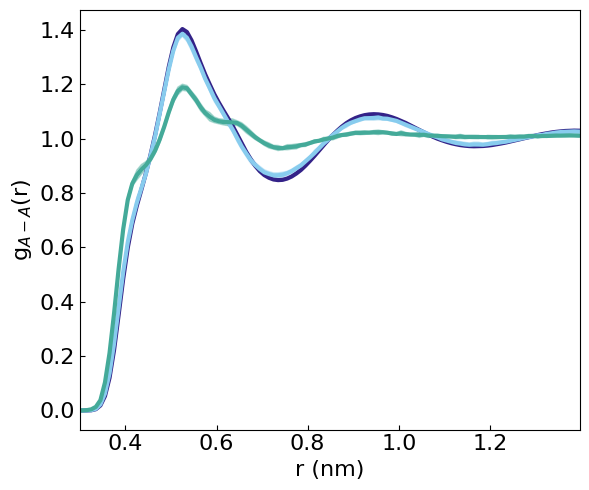

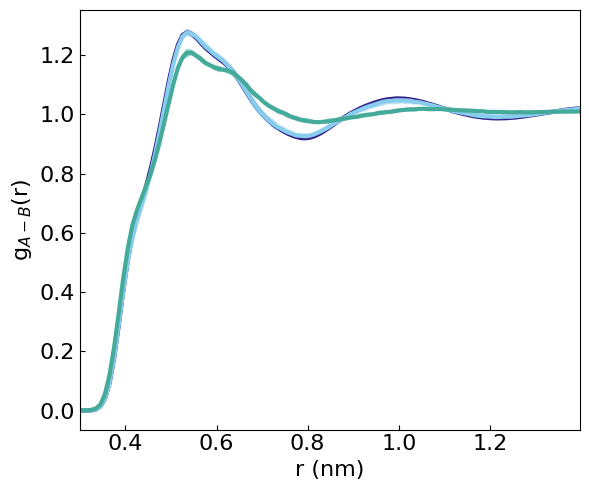

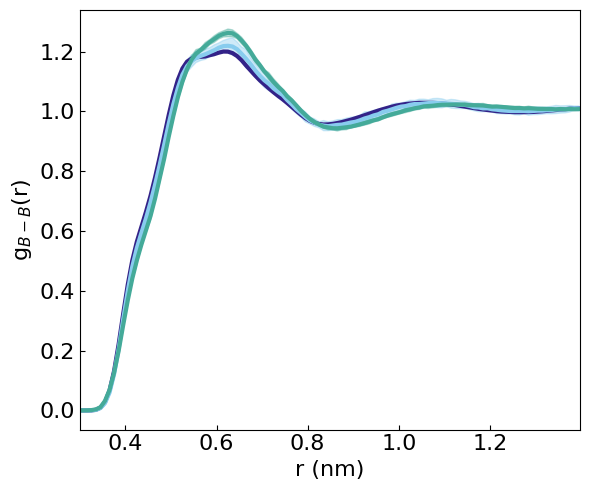

In [82]:
trajectories = [
    np.array(results['four-site']['ref']['traj']),
    np.array(results['four-site']['mace']['N=20']['corr=2']['traj']),
    np.array(results['four-site']['classical']['traj'])
]

labels = [
    'Reference',
    'MLP',
    'Classical'
]

n_chains = 10
is_single_chain = [traj.ndim == 3 for traj in trajectories]
rdf_data_all_chains = []

for chain in range(n_chains):
    trajs_single_chain = []
    for traj_chain, single in zip(trajectories, is_single_chain):
        if single:
            # Reference → do NOT index by chain
            trajs_single_chain.append(traj_chain)
        else:
            # ML models → pick chain
            trajs_single_chain.append(traj_chain[chain])

    rdf_data_chain, bead_combos = calculate_rdf(
        trajs_single_chain,
        ['A','B','B','A'],
        sites_per_mol=4,
        pair_batch_size=10_000,
        frame_batch_size=1_000
    )
    rdf_data_all_chains.append(rdf_data_chain)


merged_rdf = {}

for bead_combo in bead_combos:
    merged_rdf[bead_combo] = {}

    for traj_idx in range(len(trajectories)):

        chain_curves = []
        for chain_idx in range(n_chains):
            r, g_r = rdf_data_all_chains[chain_idx][bead_combo][traj_idx]
            chain_curves.append((r, g_r))

        merged_rdf[bead_combo][traj_idx] = chain_curves


for bead_combo in bead_combos:
    for traj_idx in merged_rdf[bead_combo]:
        curves = merged_rdf[bead_combo][traj_idx]

        r_vals = np.array([c[0] for c in curves])   # shape (n_chains, bins)
        g_vals = np.array([c[1] for c in curves])   # shape (n_chains, bins)

        merged_rdf[bead_combo][traj_idx] = (r_vals, g_vals)

results['four-site']['rdf'] = merged_rdf

plot_rdf(
    merged_rdf,
    bead_combos,
    labels,
    mode="multi",  
    n_std=3.0,
    show_legend=False,
    save_pdf=False
)

Reference shape: (500000, 400, 3)
MLP shape: (10, 2000, 400, 3)
Classical shape: (10, 2001, 400, 3)
Number of atoms: 400
Number of molecules: 100
Species array length: 400
Processing Reference...
[ADF] Estimates 1176484 max. triplets in neighbor list and 1174856 max. triplets in cutoff-shell.


/home/franz/miniconda3/envs/supramol/lib/python3.11/site-packages/jax/_src/numpy/reductions.py:221: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in sum is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return _reduction(a, "sum", np.sum, lax.add, 0, preproc=_cast_to_numeric,


[ADF] Estimates 1176484 max. triplets in neighbor list and 1174856 max. triplets in cutoff-shell.
Processing MLP chain 1/10...
[ADF] Estimates 1156436 max. triplets in neighbor list and 1154620 max. triplets in cutoff-shell.


/home/franz/miniconda3/envs/supramol/lib/python3.11/site-packages/jax/_src/numpy/reductions.py:221: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in sum is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return _reduction(a, "sum", np.sum, lax.add, 0, preproc=_cast_to_numeric,


[ADF] Estimates 1156436 max. triplets in neighbor list and 1154620 max. triplets in cutoff-shell.
Processing MLP chain 2/10...
[ADF] Estimates 1179784 max. triplets in neighbor list and 1178104 max. triplets in cutoff-shell.


...

[ADF] Estimates 1146400 max. triplets in neighbor list and 1144000 max. triplets in cutoff-shell.
Processing Classical chain 9/10...
[ADF] Estimates 1159616 max. triplets in neighbor list and 1158120 max. triplets in cutoff-shell.


/home/franz/miniconda3/envs/supramol/lib/python3.11/site-packages/jax/_src/numpy/reductions.py:221: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in sum is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return _reduction(a, "sum", np.sum, lax.add, 0, preproc=_cast_to_numeric,


[ADF] Estimates 1159616 max. triplets in neighbor list and 1158120 max. triplets in cutoff-shell.
Processing Classical chain 10/10...
[ADF] Estimates 1173620 max. triplets in neighbor list and 1171828 max. triplets in cutoff-shell.


/home/franz/miniconda3/envs/supramol/lib/python3.11/site-packages/jax/_src/numpy/reductions.py:221: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in sum is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return _reduction(a, "sum", np.sum, lax.add, 0, preproc=_cast_to_numeric,


[ADF] Estimates 1173620 max. triplets in neighbor list and 1171828 max. triplets in cutoff-shell.


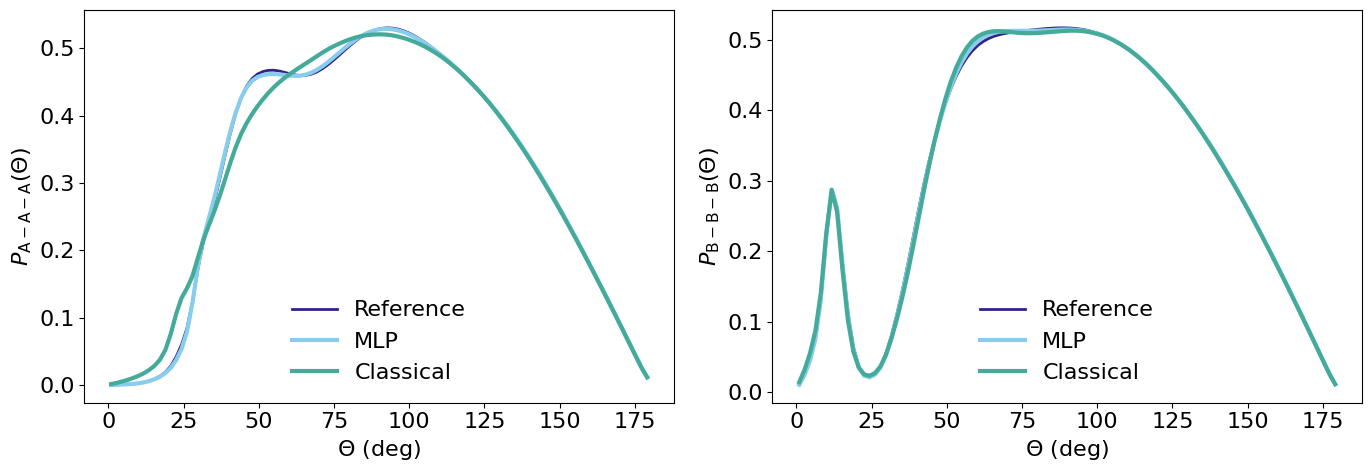

In [ ]:
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from typing import NamedTuple

# Imports from your environment
from jax_md_mod.custom_quantity import adf_discretization, ADFParams

# 1. Boilerplate / Helper Classes
class State(NamedTuple):
    position: jnp.ndarray

# --- 2. Configuration ---

N_BINS = 100
R_INNER = 0.0
R_OUTER =  0.8
BOX_SIZE = BOX_LENGTH

# Discretization
bin_centers, sigma_adf = adf_discretization(nbins=N_BINS)
params = ADFParams(
    reference=None, 
    adf_bin_centers=bin_centers, 
    sigma=sigma_adf, 
    r_outer=R_OUTER, 
    r_inner=R_INNER
)

# --- 3. Data Processing ---

# Flatten trajectories properly to (n_frames, n_atoms, 3)
ref_sub = results['four-site']['ref']['traj']#[::10]
n_atoms = 400
n_molecules = n_atoms // 4

# Keep trajectories as (n_chains, n_frames, n_atoms, 3)
mlp_traj = np.array(results['four-site']['mace']['N=20']['corr=2']['traj'])[:10,:,:,:]
cla_traj = np.array(results['four-site']['classical']['traj'])[:,:,:,:]

# Check shape 
print("Reference shape:", ref_sub.shape)
print("MLP shape:", mlp_traj.shape)
print("Classical shape:", cla_traj.shape)
print("Number of atoms:", n_atoms)
print("Number of molecules:", n_molecules)

# Species Setup for molecules with 4 atoms each (A-B-B-A pattern)
species_single_mol = jnp.array([0, 1, 1, 0])
species_all = jnp.tile(species_single_mol, n_molecules)

# Verify species array matches atom count
print("Species array length:", len(species_all))
assert len(species_all) == n_atoms, f"Species length {len(species_all)} != n_atoms {n_atoms}"

AAA_triplet = jnp.array([[0, 0, 0]])
BBB_triplet = jnp.array([[1, 1, 1]])

# Process reference (single trajectory)
print("Processing Reference...")
ref_aaa = calculate_species_adf(ref_sub, species_all, AAA_triplet, disp_fn_X, params, BOX_SIZE)
ref_bbb = calculate_species_adf(ref_sub, species_all, BBB_triplet, disp_fn_X, params, BOX_SIZE)

# Process each chain individually for MLP and Classical
n_chains_mlp = mlp_traj.shape[0]
n_chains_cla = cla_traj.shape[0]

mlp_aaa_chains = []
mlp_bbb_chains = []
for i in range(n_chains_mlp):
    print(f"Processing MLP chain {i+1}/{n_chains_mlp}...")
    mlp_aaa_chains.append(calculate_species_adf(mlp_traj[i], species_all, AAA_triplet, disp_fn_X, params, BOX_SIZE))
    mlp_bbb_chains.append(calculate_species_adf(mlp_traj[i], species_all, BBB_triplet, disp_fn_X, params, BOX_SIZE))

cla_aaa_chains = []
cla_bbb_chains = []
for i in range(n_chains_cla):
    print(f"Processing Classical chain {i+1}/{n_chains_cla}...")
    cla_aaa_chains.append(calculate_species_adf(cla_traj[i], species_all, AAA_triplet, disp_fn_X, params, BOX_SIZE))
    cla_bbb_chains.append(calculate_species_adf(cla_traj[i], species_all, BBB_triplet, disp_fn_X, params, BOX_SIZE))

# Convert to arrays for mean/std calculation
mlp_aaa_arr = np.array(mlp_aaa_chains)
mlp_bbb_arr = np.array(mlp_bbb_chains)
cla_aaa_arr = np.array(cla_aaa_chains)
cla_bbb_arr = np.array(cla_bbb_chains)


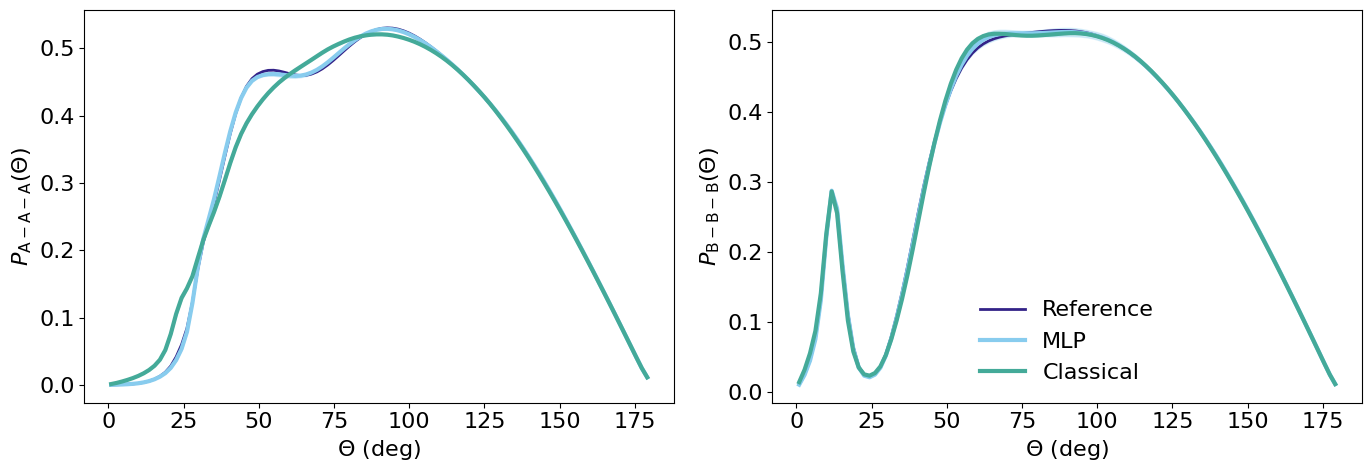

In [251]:
from cgbench.plotting import style

style.setup_plot_style()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
theta_deg = jnp.degrees(bin_centers)

n_std = 3

# AAA plot
ax1.plot(theta_deg, ref_aaa, label='Reference', lw=2, color=style.color_ref)
ax1.plot(theta_deg, mlp_aaa_arr.mean(axis=0), label='MLP', color=style.color_mace)
ax1.fill_between(theta_deg, mlp_aaa_arr.mean(axis=0) - n_std * mlp_aaa_arr.std(axis=0), 
                 mlp_aaa_arr.mean(axis=0) + n_std * mlp_aaa_arr.std(axis=0), alpha=0.3, color=style.color_mace)
ax1.plot(theta_deg, cla_aaa_arr.mean(axis=0), label='Classical', color=style.color_fm)
ax1.fill_between(theta_deg, cla_aaa_arr.mean(axis=0) - n_std * cla_aaa_arr.std(axis=0),
                 cla_aaa_arr.mean(axis=0) + n_std * cla_aaa_arr.std(axis=0), alpha=0.3, color=style.color_fm)
ax1.set_xlabel(r'$\Theta$ (deg)')
ax1.set_ylabel(r"$P_{\mathrm{A-A-A}}(\Theta)$")

# BBB plot
ax2.plot(theta_deg, ref_bbb, label='Reference', lw=2, color=style.color_ref)
ax2.plot(theta_deg, mlp_bbb_arr.mean(axis=0), label='MLP', color=style.color_mace)
ax2.fill_between(theta_deg, mlp_bbb_arr.mean(axis=0) - n_std * mlp_bbb_arr.std(axis=0), 
                 mlp_bbb_arr.mean(axis=0) + n_std * mlp_bbb_arr.std(axis=0), alpha=0.3, color=style.color_mace)
ax2.plot(theta_deg, cla_bbb_arr.mean(axis=0), label='Classical', color=style.color_fm)
ax2.fill_between(theta_deg, cla_bbb_arr.mean(axis=0) - n_std * cla_bbb_arr.std(axis=0),
                 cla_bbb_arr.mean(axis=0) + n_std * cla_bbb_arr.std(axis=0), alpha=0.3, color=style.color_fm)
ax2.set_xlabel(r'$\Theta$ (deg)')
ax2.set_ylabel(r"$P_{\mathrm{B-B-B}}(\Theta)$")
ax2.legend(frameon=False)

plt.tight_layout()
plt.savefig("hexane_four_site_adf.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:

from cgbench.plotting import style

style.setup_plot_style()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
theta_deg = jnp.degrees(bin_centers)

# AAA plot
ax1.plot(theta_deg, ref_aaa, label='Reference', lw=2, color=style.color_ref)
ax1.plot(theta_deg, mlp_aaa_arr.mean(axis=0), label='MLP', color=style.color_mace)
ax1.fill_between(theta_deg, mlp_aaa_arr.mean(axis=0) - mlp_aaa_arr.std(axis=0), 
                 mlp_aaa_arr.mean(axis=0) + mlp_aaa_arr.std(axis=0), alpha=0.3, color=style.color_mace)
ax1.plot(theta_deg, cla_aaa_arr.mean(axis=0), label='Classical', color=style.color_fm)
ax1.fill_between(theta_deg, cla_aaa_arr.mean(axis=0) - cla_aaa_arr.std(axis=0),
                 cla_aaa_arr.mean(axis=0) + cla_aaa_arr.std(axis=0), alpha=0.3, color=style.color_fm)
ax1.set_xlabel(r'$\Theta$ (deg)')
ax1.set_ylabel(r"$P_{\mathrm{A-A-A}}(\Theta)$")
ax1.legend(frameon=False)

# BBB plot
ax2.plot(theta_deg, ref_bbb, label='Reference', lw=2, color=style.color_ref)
ax2.plot(theta_deg, mlp_bbb_arr.mean(axis=0), label='MLP', color=style.color_mace)
ax2.fill_between(theta_deg, mlp_bbb_arr.mean(axis=0) - mlp_bbb_arr.std(axis=0), 
                 mlp_bbb_arr.mean(axis=0) + mlp_bbb_arr.std(axis=0), alpha=0.3, color=style.color_mace)
ax2.plot(theta_deg, cla_bbb_arr.mean(axis=0), label='Classical', color=style.color_fm)
ax2.fill_between(theta_deg, cla_bbb_arr.mean(axis=0) - cla_bbb_arr.std(axis=0),
                 cla_bbb_arr.mean(axis=0) + cla_bbb_arr.std(axis=0), alpha=0.3, color=style.color_fm)
ax2.set_xlabel(r'$\Theta$ (deg)')
ax2.set_ylabel(r"$P_{\mathrm{B-B-B}}(\Theta)$")
ax2.legend(frameon=False)

plt.tight_layout()
plt.savefig("hexane_four_site_adf.pdf", dpi=300, bbox_inches='tight')
plt.show()


## Composite graphic

In [ ]:
bo = 'corr=2'
N = 'N=20'
n_std = 3.0
n_chains = 10 # show 10 stable chains

Processing bond data for 'Reference': (50000000,)
Processing bond data for 'MACE (Nearest Neighbor)': (10, 400000)
Plotting bond distribution for 'MACE (Nearest Neighbor)': 10 chains, mean=1.0, std sum=0.013049154361194311
Processing bond data for 'Classical': (10, 200100)
Plotting bond distribution for 'Classical': 10 chains, mean=1.0, std sum=0.01506299990966747


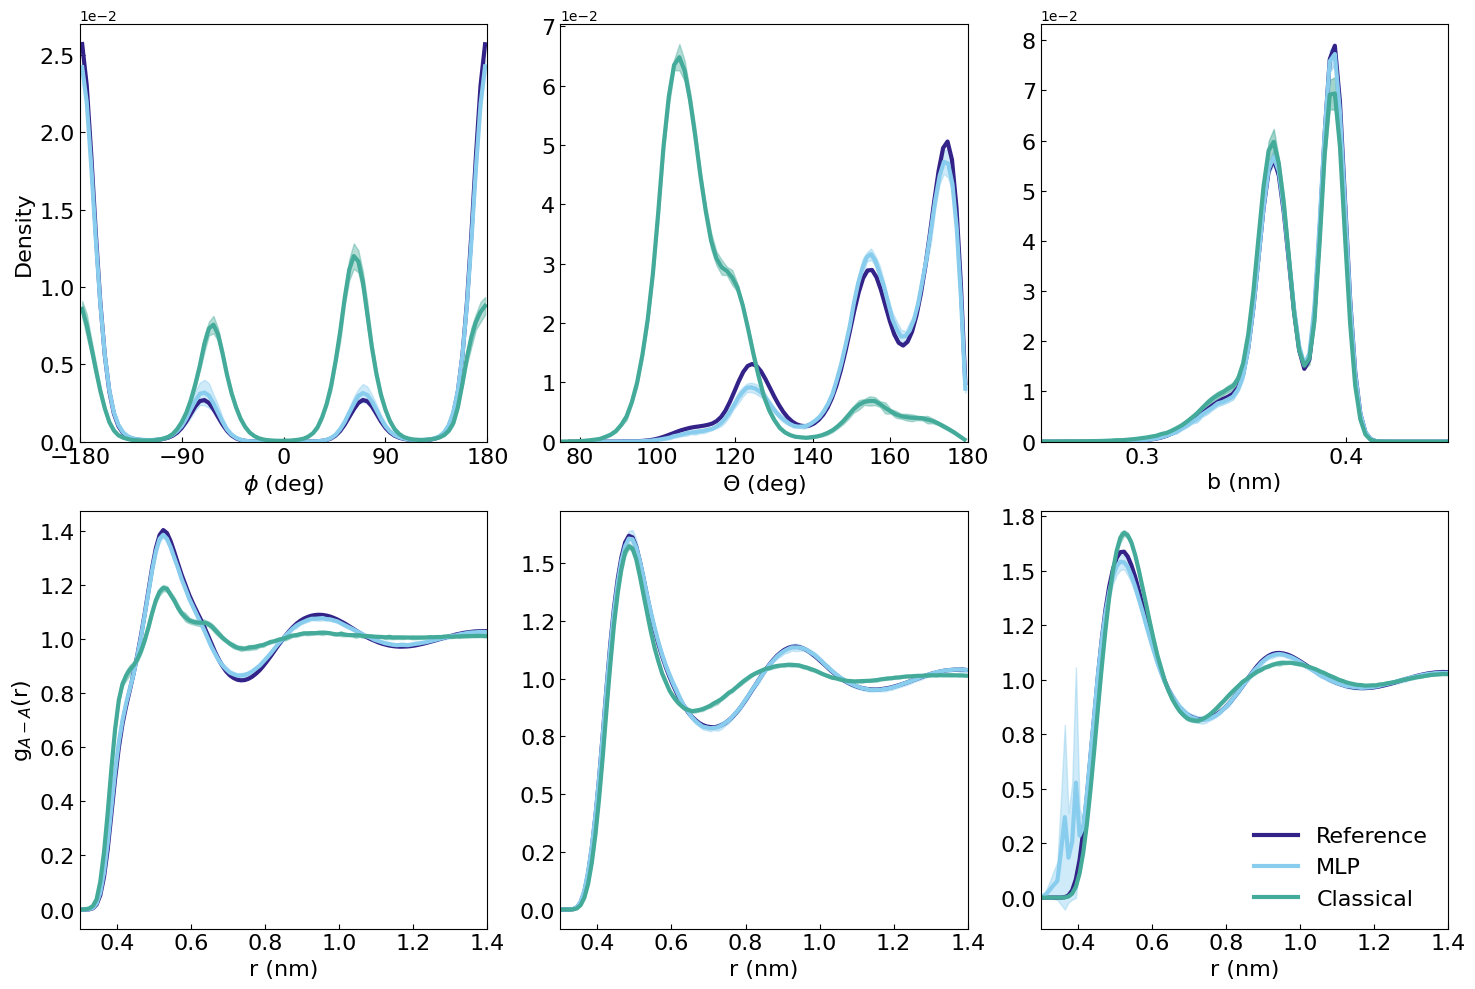

In [139]:
import importlib
import structural_analysis_utils
importlib.reload(structural_analysis_utils)
import matplotlib.pyplot as plt

labels = [
    'Reference', 
    'MLP', 
    'Classical'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.2, wspace=0.2)  # Adjust spacing between subplots

structural_analysis_utils.plot_1d_dihedral(
    axes[0, 0], 
    [
        results['four-site']['ref']['dihedrals'],
        results['four-site']['mace'][N][bo]['dihedrals'][:n_chains,],
        results['four-site']['classical']['dihedrals']
    ],
    ['Reference', 'MACE', 'Classical'],
    bins=90,
    ylabel=True,
    plot_legend=False,
    xlabel='$\phi$ (deg)',
    tick_bin=90,
    mode='multi',
    n_std=n_std,
)

structural_analysis_utils.plot_1d_angle(
    axes[0, 1], 
    [
        results['three-site']['ref']['angles'],
        results['three-site']['mace'][N][bo]['angles'][:n_chains,],
        results['three-site']['classical']['angles']
    ],  
    ['Reference', 'MLP', 'Classical'],
    bins=90,
    ylabel=False,
    plot_legend=False,
    xlabel='$\Theta$ (deg)',
    degrees=True,
    mode='multi',
    n_std=n_std,
)
axes[0, 1].set_xlim(75, 180)

structural_analysis_utils.plot_1d_bond(
    axes[0, 2], 
    [
        results['two-site']['ref']['bonds'],
        results['two-site']['mace'][N][bo]['nn_distances'][:n_chains,],
        results['two-site']['classical']['bonds']
    ],
    [
        'Reference', 
        'MACE (Nearest Neighbor)', 
        'Classical'
    ],
    bins=150,
    plot_legend=False,
    ylabel=False,
    xlabel='b (nm)',
    tick_bin=0.1,
    mode='multi',
    n_std=n_std,
)
axes[0, 2].set_xlim(0.25, 0.45)


structural_analysis_utils.plot_1d_rdf(
    axes[1, 0], 
    results['four-site']['rdf'], 
    ('A', 'A'), 
    labels, 
    ylabel=True,
    plot_legend=False,
    mode='multi',
    n_std=n_std,
)
axes[1, 0].set_xlim(0.3, 1.4)

structural_analysis_utils.plot_1d_rdf(
    axes[1, 1], 
    results['three-site']['rdf'], 
    ('A', 'A'), 
    labels, 
    ylabel=False,
    plot_legend=False,
    mode='multi',
    n_std=n_std,
)
axes[1, 1].set_xlim(0.3, 1.4)

structural_analysis_utils.plot_1d_rdf(
    axes[1, 2], 
    results['two-site']['rdf'], 
    ('A', 'A'), 
    labels, 
    ylabel=False,
    plot_legend=True,
    mode='multi',
    n_std=n_std,
)
axes[1, 2].set_xlim(0.3, 1.4)


    
from matplotlib.ticker import ScalarFormatter
import matplotlib.pyplot as plt

# Reset formatters first
for i in range(2):
    for j in range(3):
        axes[i, j].yaxis.set_major_formatter(ScalarFormatter())

# Apply scientific notation
for i in range(2):
    for j in range(3):
        axes[i, j].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Override a specific axis with 1-decimal formatting
axes[1, 2].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.1f}')
)
# Override a specific axis with 1-decimal formatting
axes[1, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.1f}')
)


plt.tight_layout()
plt.savefig("Hexane/Hexane_combined_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')

Processing bond data for 'Reference': (100000000,)
Processing bond data for 'MLP': (9, 400000)
Plotting bond distribution for 'MLP': 9 chains, mean=1.0, std sum=0.010753507571253092
Processing bond data for 'Classical': (10, 400200)
Plotting bond distribution for 'Classical': 10 chains, mean=1.0, std sum=0.01030685549439278


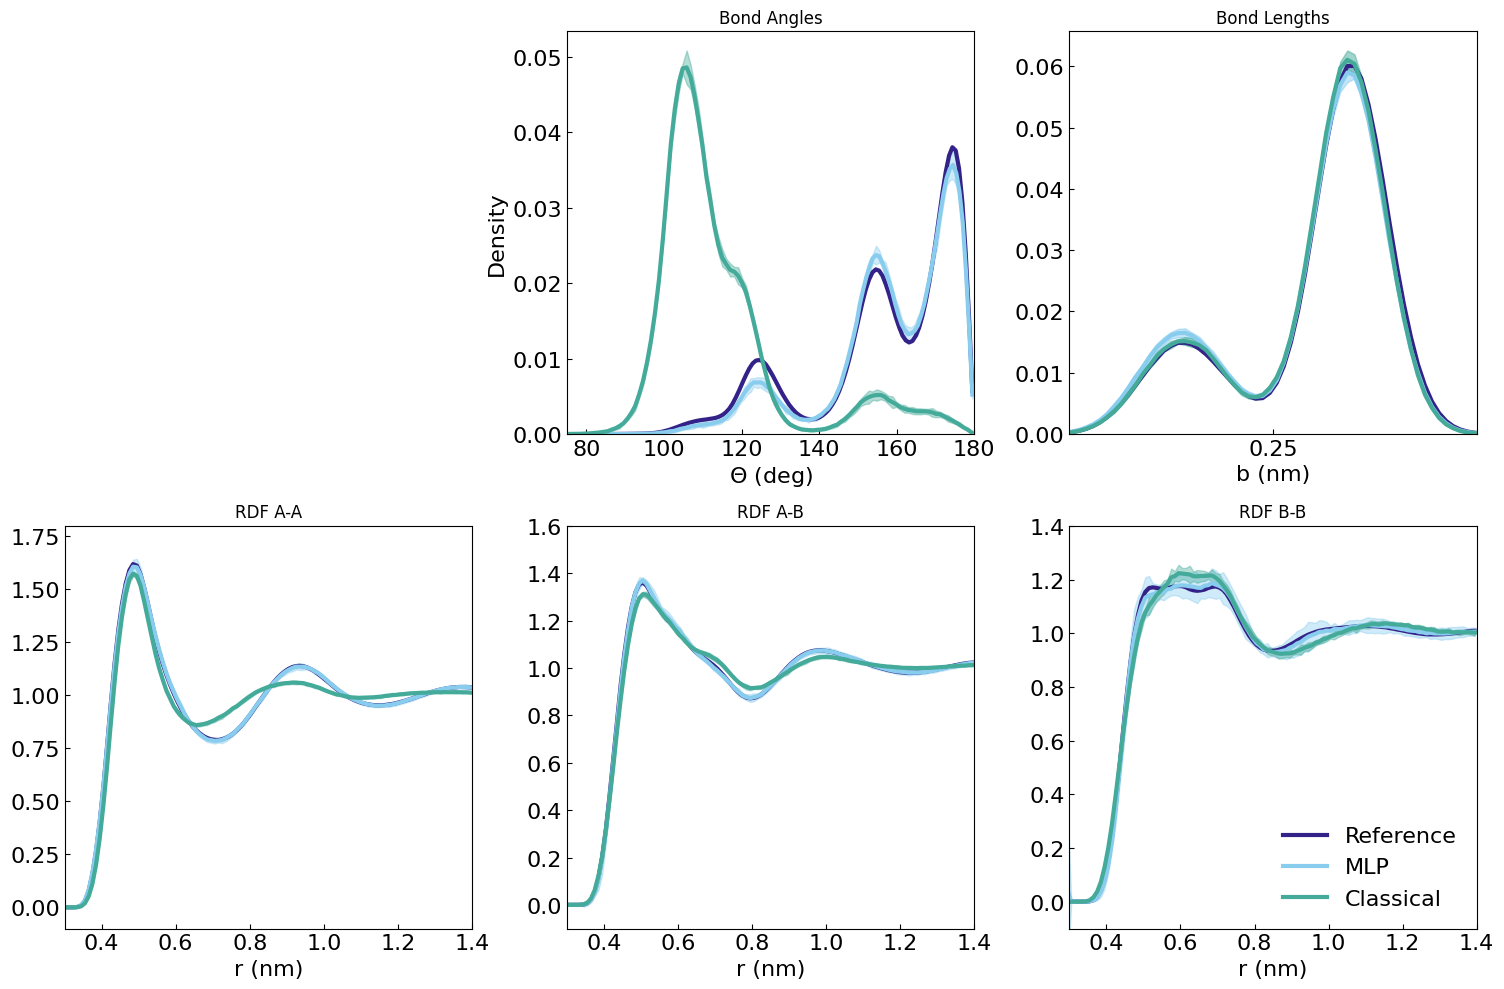

In [150]:
import matplotlib.pyplot as plt

# Create a 2-row, 3-column plot layout
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)  # Adjust spacing between subplots

# Leave the first cell empty
axes[0, 0].axis('off')



# Plot bond angles
plot_1d_angle(
    axes[0, 1],
    [
        results['three-site']['ref']['angles'],
        results['three-site']['mace'][N][bo]['angles'][:n_chains,],
        results['three-site']['classical']['angles']
    ],
    ['Reference', 'MLP', 'Classical'],
    bins=120,
    degrees=True,
    xlabel='$\\Theta$ (deg)',
    ylabel=True,
    plot_legend=False,
    mode='multi',
    n_std=n_std,
)
axes[0, 1].set_title('Bond Angles')
axes[0, 1].set_xlim(75, 180)

# Plot bond lengths
plot_1d_bond(
    axes[0, 2],
    [
        results['three-site']['ref']['bonds'],
        results['three-site']['mace'][N][bo]['bonds'][:n_chains,],
        results['three-site']['classical']['bonds']
    ],
    ['Reference', 'MLP', 'Classical'],
    bins=90,
    xlabel='b (nm)',
    ylabel=False,
    plot_legend=False,
    tick_bin=0.05,
    mode='multi',
    n_std=n_std,
)
axes[0, 2].set_title('Bond Lengths')
axes[0, 2].set_xlim(0.22, 0.28)

# Plot RDF for A-A
structural_analysis_utils.plot_1d_rdf(
    axes[1, 0], 
    results['three-site']['rdf'], 
    ('A', 'A'),
    labels,
    xlabel='r (nm)',
    ylabel=False,
    plot_legend=False,
    mode='multi',
    n_std=n_std,
)
axes[1, 0].set_title('RDF A-A')
axes[1, 0].set_xlim(0.3, 1.4)
axes[1, 0].set_ylim(-0.1, 1.8)

# Plot RDF for A-B
structural_analysis_utils.plot_1d_rdf(
    axes[1, 1], 
    results['three-site']['rdf'], 
    ('A', 'B'), 
    labels,
    xlabel='r (nm)',
    ylabel=False,
    plot_legend=False,
    mode='multi',
    n_std=n_std,
)
axes[1, 1].set_title('RDF A-B')
axes[1, 1].set_xlim(0.3, 1.4)
axes[1, 1].set_ylim(-0.1, 1.6)

# Plot RDF for B-B
structural_analysis_utils.plot_1d_rdf(
    axes[1, 2], 
    results['three-site']['rdf'], 
    ('B', 'B'), 
    labels,
    xlabel='r (nm)',
    ylabel=False,
    plot_legend=True,
    mode='multi',
    n_std=n_std,
)
axes[1, 2].set_title('RDF B-B')
axes[1, 2].set_xlim(0.3, 1.4)
axes[1, 2].set_ylim(-0.1, 1.4)

# Save the plot as a PDF
plt.tight_layout()
plt.savefig("Hexane/Three-site_combined_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

Processing bond data for 'Reference': (100000000,)
Processing bond data for 'MLP': (10, 400000)
Plotting bond distribution for 'MLP': 10 chains, mean=1.0, std sum=0.008957956613433269
Processing bond data for 'Classical': (10, 400200)
Plotting bond distribution for 'Classical': 10 chains, mean=0.9999999999999999, std sum=0.008930159101208174


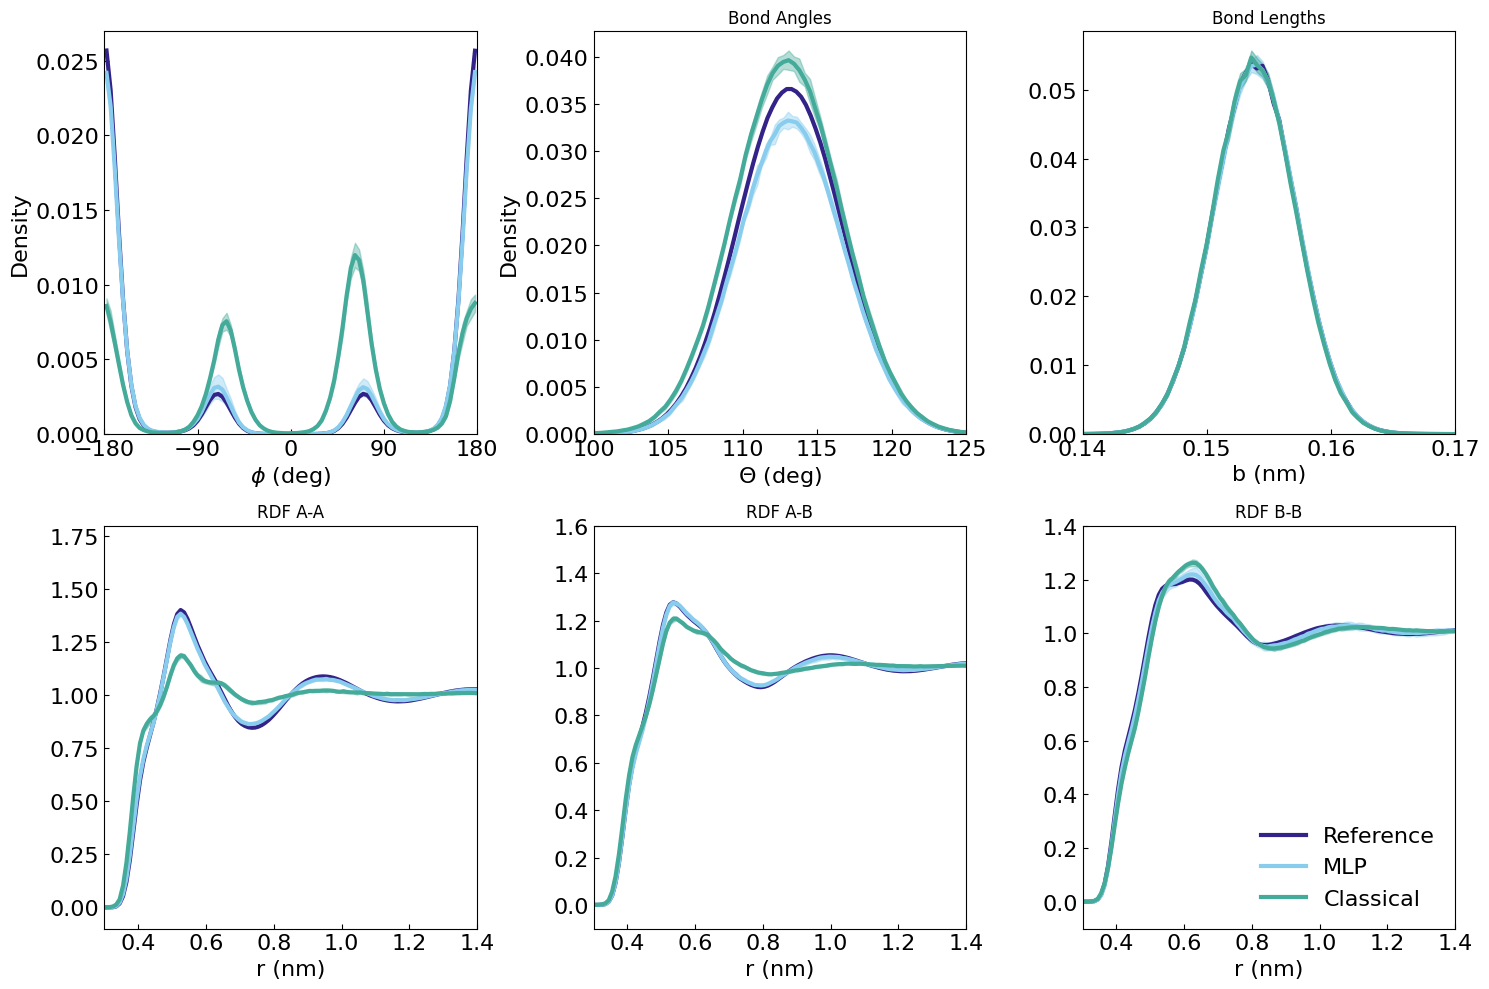

In [156]:
import matplotlib.pyplot as plt

# Create a 2-row, 3-column plot layout
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)  # Adjust spacing between subplots

structural_analysis_utils.plot_1d_dihedral(
    axes[0, 0], 
    [
        results['four-site']['ref']['dihedrals'],
        results['four-site']['mace'][N][bo]['dihedrals'][:n_chains,],
        results['four-site']['classical']['dihedrals']
    ],
    ['Reference', 'MACE', 'Classical'],
    bins=90,
    ylabel=True,
    plot_legend=False,
    xlabel='$\phi$ (deg)',
    tick_bin=90,
    mode='multi',
    n_std=n_std,
)


# Plot bond angles
plot_1d_angle(
    axes[0, 1],
    [
        results['four-site']['ref']['angles'],
        results['four-site']['mace'][N][bo]['angles'][:n_chains,],
        np.radians(results['four-site']['classical']['angles'])
    ],
    ['Reference', 'MLP', 'Classical'],
    bins=120,
    degrees=True,
    xlabel='$\\Theta$ (deg)',
    ylabel=True,
    plot_legend=False,
    mode='multi',
    n_std=n_std,
)
axes[0, 1].set_title('Bond Angles')
axes[0, 1].set_xlim(100,125)

# Plot bond lengths
plot_1d_bond(
    axes[0, 2],
    [
        results['four-site']['ref']['bonds'],
        results['four-site']['mace'][N][bo]['bonds'][:n_chains,],
        results['four-site']['classical']['bonds']
    ],
    ['Reference', 'MLP', 'Classical'],
    bins=90,
    xlabel='b (nm)',
    ylabel=False,
    plot_legend=False,
    tick_bin=0.01,
    mode='multi',
    n_std=n_std,
)
axes[0, 2].set_title('Bond Lengths')
axes[0, 2].set_xlim(0.14, 0.17)

# Plot RDF for A-A
structural_analysis_utils.plot_1d_rdf(
    axes[1, 0], 
    results['four-site']['rdf'], 
    ('A', 'A'),
    labels,
    xlabel='r (nm)',
    ylabel=False,
    plot_legend=False,
    mode='multi',
    n_std=n_std,
)
axes[1, 0].set_title('RDF A-A')
axes[1, 0].set_xlim(0.3, 1.4)
axes[1, 0].set_ylim(-0.1, 1.8)

# Plot RDF for A-B
structural_analysis_utils.plot_1d_rdf(
    axes[1, 1], 
    results['four-site']['rdf'], 
    ('A', 'B'), 
    labels,
    xlabel='r (nm)',
    ylabel=False,
    plot_legend=False,
    mode='multi',
    n_std=n_std,
)
axes[1, 1].set_title('RDF A-B')
axes[1, 1].set_xlim(0.3, 1.4)
axes[1, 1].set_ylim(-0.1, 1.6)

# Plot RDF for B-B
structural_analysis_utils.plot_1d_rdf(
    axes[1, 2], 
    results['four-site']['rdf'], 
    ('B', 'B'), 
    labels,
    xlabel='r (nm)',
    ylabel=False,
    plot_legend=True,
    mode='multi',
    n_std=n_std,
)
axes[1, 2].set_title('RDF B-B')
axes[1, 2].set_xlim(0.3, 1.4)
axes[1, 2].set_ylim(-0.1, 1.4)

# Save the plot as a PDF
plt.tight_layout()
plt.savefig("Hexane/Four-site_combined_analysis.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

# Body Order Plots

In [159]:
results_body_order = {}
results_body_order['three-site'] = {
    'ref': results['three-site']['ref']
}

In [ ]:
line_locs = utils.get_line_locations(0, 1000, 50, print_every=0.5)

###
path_int1_corr1 = "Hexane/MLP/Hexane_map=three-site_rcut=0.7_corr=1_int=1/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl"
mace_traj = np.load(path_int1_corr1, allow_pickle=True)
mace_traj *= box[0,0]
mace_traj = utils.chains.split_into_chains(mace_traj, line_locs)

angles_mace = [angle_util['three-site']['disp_X'](chain) for chain in mace_traj]  # [N_angle_idcs, n_frames]
angles_mace = [np.radians(np.concatenate(chain)) for chain in angles_mace]

bonds_mace = []
for chain in mace_traj:
    bonds_chain = []
    for a, b in bond_util['three-site']['idcs']:
        distances = utils.geometry.compute_atom_distance(chain, a, b, bond_util['three-site']['disp_X'])
        bonds_chain.append(distances)
    bonds_mace.append(np.concatenate(bonds_chain))


results_body_order['three-site']['int1_corr1'] = {
    'angles': np.array(angles_mace),
    'bonds': np.array(bonds_mace),
    'traj': mace_traj
}

###
path_int1_corr2 = "Hexane/MLP/Hexane_map=three-site_rcut=0.7_corr=2_int=1/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl"
mace_traj = np.load(path_int1_corr2, allow_pickle=True)
mace_traj *= box[0,0]
mace_traj = utils.chains.split_into_chains(mace_traj, line_locs)

angles_mace = [angle_util['three-site']['disp_X'](chain) for chain in mace_traj]  # [N_angle_idcs, n_frames]
angles_mace = [np.radians(np.concatenate(chain)) for chain in angles_mace]

bonds_mace = []
for chain in mace_traj:
    bonds_chain = []
    for a, b in bond_util['three-site']['idcs']:
        distances = utils.geometry.compute_atom_distance(chain, a, b, bond_util['three-site']['disp_X'])
        bonds_chain.append(distances)
    bonds_mace.append(np.concatenate(bonds_chain))

results_body_order['three-site']['int1_corr2'] = {
    'angles': np.array(angles_mace),
    'bonds': np.array(bonds_mace),
    'traj': mace_traj
}

###
path_int2_corr1 = "Hexane/MLP/Hexane_map=three-site_rcut=0.7_corr=1_int=2/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=50_mode=sampling_seed=22/trajectory.pkl"
mace_traj = np.load(path_int2_corr1, allow_pickle=True)
mace_traj *= box[0,0]
mace_traj = utils.chains.split_into_chains(mace_traj, line_locs)

angles_mace = [angle_util['three-site']['disp_X'](chain) for chain in mace_traj]  # [N_angle_idcs, n_frames]
angles_mace = [np.radians(np.concatenate(chain)) for chain in angles_mace]

bonds_mace = []
for chain in mace_traj:
    bonds_chain = []
    for a, b in bond_util['three-site']['idcs']:
        distances = utils.geometry.compute_atom_distance(chain, a, b, bond_util['three-site']['disp_X'])
        bonds_chain.append(distances)
    bonds_mace.append(np.concatenate(bonds_chain))

results_body_order['three-site']['int2_corr1'] = {
    'angles': np.array(angles_mace),
    'bonds': np.array(bonds_mace),
    'traj': mace_traj
}

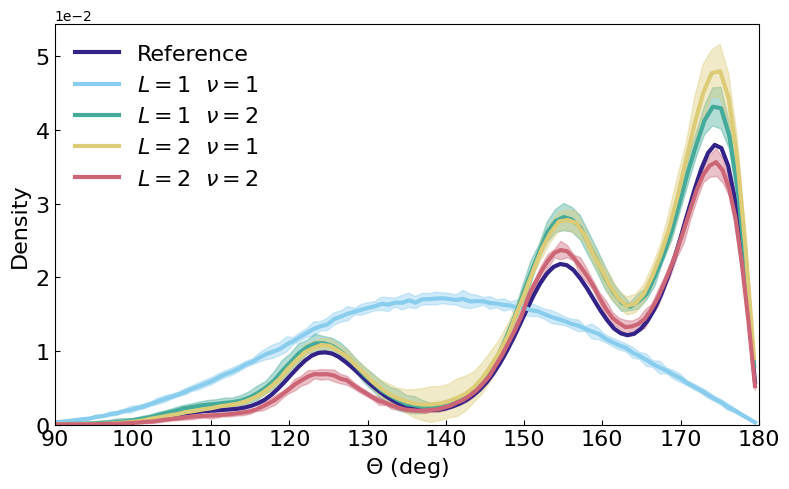

In [178]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
plt.subplots_adjust(hspace=0.2, wspace=0.2)  # Adjust spacing between subplots

labels = ['Reference', r'$L=1$  $\nu=1$', r'$L=1$  $\nu=2$', r'$L=2$  $\nu=1$', r'$L=2$  $\nu=2$']

plot_1d_angle(
    ax, 
    [
        results_body_order['three-site']['ref']['angles'],
        results_body_order['three-site']['int1_corr1']['angles'][:n_chains,],
        results_body_order['three-site']['int1_corr2']['angles'][:n_chains,],
        results_body_order['three-site']['int2_corr1']['angles'][:n_chains,],
        results['three-site']['mace'][N][bo]['angles'][:n_chains,], # Re-use previous MACE data
    ],  
    labels,
    bins=120,
    ylabel=True,
    plot_legend=True,
    xlabel='$\Theta$ (deg)',
    degrees=True,
    mode='multi',
    n_std=3
)
plt.xlim(90, 180)
# make y-axis use scientific notation
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.savefig("Hexane/Three-site_Angle_L=1-2_v=1-2_std=3.pdf", format='pdf', dpi=300, bbox_inches='tight')

In [ ]:
line_locs = utils.get_line_locations(0, 1000, 10, print_every=0.5)

results_body_order = {}
results_body_order['two-site'] = {
    'ref': results['two-site']['ref']
}
###
path_int1_corr1 = "../results/Hexane/MLP/Hexane_map=two-site_rcut=0.8_corr=1_int=1/simulation_NVT/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=10_mode=sampling_seed=22/trajectory.pkl"
mace_traj = np.load(path_int1_corr1, allow_pickle=True)
mace_traj *= box[0,0]
mace_traj = utils.chains.split_into_chains(mace_traj, line_locs)

bonds_mace = []
for chain in mace_traj:
    bonds_chain = []
    for a, b in bond_util['two-site']['idcs']:
        distances = utils.geometry.compute_atom_distance(chain, a, b, bond_util['two-site']['disp_X'])
        bonds_chain.append(distances)
    bonds_mace.append(np.concatenate(bonds_chain))

results_body_order['two-site']['int1_corr1'] = {
    'bonds': np.array(bonds_mace),
    'traj': mace_traj
}

###
path_int1_corr2 = "../results/Hexane/MLP/Hexane_map=two-site_rcut=0.8_corr=2_int=1/simulation_NVT/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=10_mode=sampling_seed=22/trajectory.pkl"
mace_traj = np.load(path_int1_corr2, allow_pickle=True)
mace_traj *= box[0,0]
mace_traj = utils.chains.split_into_chains(mace_traj, line_locs)

bonds_mace = []
for chain in mace_traj:
    bonds_chain = []
    for a, b in bond_util['two-site']['idcs']:
        distances = utils.geometry.compute_atom_distance(chain, a, b, bond_util['two-site']['disp_X'])
        bonds_chain.append(distances)
    bonds_mace.append(np.concatenate(bonds_chain))

results_body_order['two-site']['int1_corr2'] = {
    'bonds': np.array(bonds_mace),
    'traj': mace_traj
}

###
path_int2_corr1 = "../results/Hexane/MLP/Hexane_map=two-site_rcut=0.8_corr=1_int=2/simulation_NVT/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=10_mode=sampling_seed=22/trajectory.pkl"
mace_traj = np.load(path_int2_corr1, allow_pickle=True)
mace_traj *= box[0,0]
mace_traj = utils.chains.split_into_chains(mace_traj, line_locs)

bonds_mace = []
for chain in mace_traj:
    bonds_chain = []
    for a, b in bond_util['two-site']['idcs']:
        distances = utils.geometry.compute_atom_distance(chain, a, b, bond_util['two-site']['disp_X'])
        bonds_chain.append(distances)
    bonds_mace.append(np.concatenate(bonds_chain))

results_body_order['two-site']['int2_corr1'] = {
    'bonds': np.array(bonds_mace),
    'traj': mace_traj
}

###
path_int2_corr2 = "../results/Hexane/MLP/Hexane_map=two-site_rcut=0.8_corr=2_int=2/simulation_NVT/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=10_mode=sampling_seed=22/trajectory.pkl"
mace_traj = np.load(path_int2_corr2, allow_pickle=True)
mace_traj *= box[0,0]
mace_traj = utils.chains.split_into_chains(mace_traj, line_locs)

bonds_mace = []
for chain in mace_traj:
    bonds_chain = []
    for a, b in bond_util['two-site']['idcs']:
        distances = utils.geometry.compute_atom_distance(chain, a, b, bond_util['two-site']['disp_X'])
        bonds_chain.append(distances)
    bonds_mace.append(np.concatenate(bonds_chain))

results_body_order['two-site']['int2_corr2'] = {
    'bonds': np.array(bonds_mace),
    'traj': mace_traj
}

In [ ]:
trajectories = [
    results_body_order['two-site']['ref']['traj'],
    results_body_order['two-site']['int1_corr1']['traj'],
    results_body_order['two-site']['int1_corr2']['traj'],
    results_body_order['two-site']['int2_corr1']['traj'],
    results_body_order['two-site']['int2_corr2']['traj'],
]

labels = [
    'Reference',
    r'$L=1$  $\nu=1$',
    r'$L=1$  $\nu=2$',
    r'$L=2$  $\nu=1$',
    r'$L=2$  $\nu=2$',    
]

# Determine chain counts
n_chains = trajectories[1].shape[0]   # model trajectories

# Identify which trajectories have no chain dimension (reference)
is_single_chain = [traj.ndim == 3 for traj in trajectories]

rdf_data_all_chains = []

# 1) Compute RDF for each chain
for chain in range(n_chains):
    trajs_single_chain = []
    for traj_chain, single in zip(trajectories, is_single_chain):
        if single:
            # Reference → do NOT index by chain
            trajs_single_chain.append(traj_chain)
        else:
            # ML models → pick chain
            trajs_single_chain.append(traj_chain[chain])

    rdf_data_chain, bead_combos = utils.structural.calculate_rdf(
        trajs_single_chain,
        ['A','A'],
        sites_per_mol=2,
        pair_batch_size=10_000,
        frame_batch_size=1_000
    )
    rdf_data_all_chains.append(rdf_data_chain)


Saved RDF plot for A-A pairs to rdf_A-A.pdf
Generated 1 RDF plots saved as PDF files.


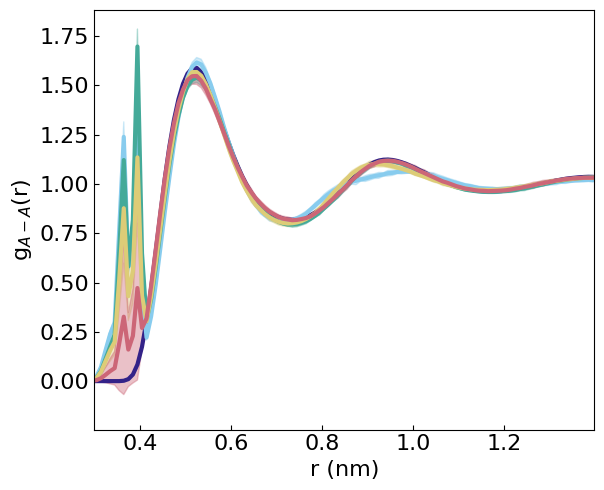

In [ ]:
merged_rdf = {}

for bead_combo in bead_combos:
    merged_rdf[bead_combo] = {}

    for traj_idx in range(len(trajectories)):

        chain_curves = []
        for chain_idx in range(n_chains):
            r, g_r = rdf_data_all_chains[chain_idx][bead_combo][traj_idx]
            chain_curves.append((r, g_r))

        merged_rdf[bead_combo][traj_idx] = chain_curves


for bead_combo in bead_combos:
    for traj_idx in merged_rdf[bead_combo]:
        curves = merged_rdf[bead_combo][traj_idx]

        r_vals = np.array([c[0] for c in curves])   # shape (n_chains, bins)
        g_vals = np.array([c[1] for c in curves])   # shape (n_chains, bins)

        merged_rdf[bead_combo][traj_idx] = (r_vals, g_vals)


utils.plotting.plot_rdf(
    merged_rdf,
    bead_combos,
    labels,
    mode="multi",   # enables mean + std shading
    n_std=3.0,
    show_legend=False
)


# NequIP

In [ ]:
results_nequip = {}

In [ ]:
path = "Reference_simulations/hexane/hexane_ttot=100ns_dt=1fs_nstxout=200_CG=two-site.npz"
data = dict(np.load(path,allow_pickle=True))
ref_traj = np.concatenate([data['arr_0'].item()['training']['R'],data['arr_0'].item()['validation']['R']])

bond_ref = [utils.geometry.compute_atom_distance(ref_traj, a, b, bond_util['two-site']['disp_X']) for a,b in bond_util['two-site']['idcs']]
bond_ref = np.concatenate(bond_ref)

results_nequip['two-site'] = {
    'ref': {
        'bonds': bond_ref,
        'traj': ref_traj
    }
}

In [ ]:
traj_path = '/home/franz/CG-Mapping-Benchmark/MLP_train_nequip/Hexane_map=two-site_tr=0.9_epochs=50/simulation_NVT_T=300.0K/traj_mol=hexane_dt=2_teq=0_t=1000_nmol=100_nchains=10_mode=sampling_seed=22/trajectory.pkl'
nequip_traj = np.load(traj_path, allow_pickle=True)
    
assert nequip_traj.shape[0] == 20000
nequip_traj *= box[0,0]

bond_nequip = [utils.geometry.compute_atom_distance(nequip_traj, a, b, bond_util['two-site']['disp_X']) for a,b in bond_util['two-site']['idcs']]
bond_nequip = np.concatenate(bond_nequip)

results_nequip['two-site']['nequip'] = {
    'bonds': bond_nequip,
    'traj': nequip_traj
}

cumulative_fraction, nearest_neighbor_distances, bonds_per_frame = \
    utils.chains.compute_bond_metrics(nequip_traj, bond_util['two-site']['disp_X'])

results_nequip['two-site']['nequip']['cumulative_switch_fraction'] = cumulative_fraction
results_nequip['two-site']['nequip']['nn_distances'] = nearest_neighbor_distances
results_nequip['two-site']['nequip']['bonds_per_frame'] = bonds_per_frame

In [ ]:
trajectories = [
    results_nequip['two-site']['ref']['traj'],
    results_nequip['two-site']['nequip']['traj'],
]
labels = [
    'Reference', 
    'NequIP (Bonds)', 
]

rdf_data, bead_combos = utils.structural.calculate_rdf(
    trajectories, 
    ['A', 'A'], 
    sites_per_mol=2,
    pair_batch_size=10_000,
    frame_batch_size=1_000 
)

results_nequip['two-site']['rdf'] = {
    'data': rdf_data,
    'combos': bead_combos,
    'labels': labels
}

utils.plotting.plot_rdf(rdf_data, bead_combos, labels, save_pdf=True, output_prefix='NequIP')

ValueError: axis 1 is out of bounds for array of dimension 1

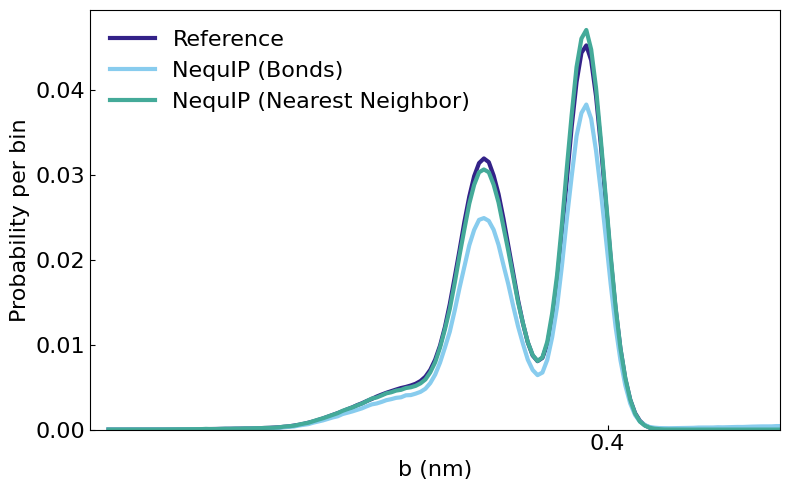

In [37]:
# make 

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

plot_1d_bond(
    axes, 
    [
        results_nequip['two-site']['ref']['bonds'],
        results_nequip['two-site']['nequip']['bonds'],
        results_nequip['two-site']['nequip']['nn_distances'].flatten(),
    ],
    [
        'Reference', 
        'NequIP (Bonds)', 
        'NequIP (Nearest Neighbor)', 
    ],
    bins=1500,
    plot_legend=True,
    ylabel=True,
    xlabel='b (nm)',
    tick_bin=0.4
)
plt.xlim(0.25, 0.45)
plt.tight_layout()
plt.savefig("NequIP_Two-site_Bond_Nearest_Neighbor.pdf", format='pdf', dpi=300, bbox_inches='tight')